<a href="https://colab.research.google.com/github/VaishnaviNehare13/AI-Digital-Evidence-Intelligence-Platform/blob/main/Multi_Model_Generative_AI_Framework_for_Digital_Evidence_Analysis_and_Intelligence_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Model Generative AI Framework for Digital Evidence Analysis and Intelligence Generation

## Transformer-Based Digital Evidence Analysis

### Cell 1: Environment Setup

This notebook implements the **Transformer-based component** of our digital evidence analysis framework.

The Transformer model is designed to analyze digital image evidence using image patches, self-attention, and image reconstruction.

### Main Steps

1. Set up the Python and PyTorch environment
2. Load and prepare the digital evidence dataset
3. Convert images into patches
4. Apply Transformer-based feature extraction
5. Learn image representations
6. Reconstruct the input image
7. Calculate reconstruction errors
8. Evaluate the model on authentic and tampered images
9. Generate visual and quantitative analysis

### Objective

The main objective of this module is to explore whether a Transformer-based model can learn useful representations of digital image evidence and support forensic image analysis.

**Note:** The system provides AI-assisted analysis and potential anomaly indicators. It does not make a legal or final forensic judgment.

In [1]:

# Cell 1: Environment Setup

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

PyTorch version : 2.11.0+cu128
Device          : cuda
GPU             : Tesla T4


# Cell 2: Project & Dataset Paths

This cell defines the folders used to store the Transformer project, model checkpoints, evaluation results, and sample outputs.

The CASIA v2.0 dataset contains authentic and tampered digital images used for training and forensic evaluation.

The project structure keeps the trained models and experimental results separate from the dataset.

In [2]:

import os

# Main project directory
PROJECT_DIR = "/content/AI-Digital-Evidence-Intelligence-Platform"

# Transformer-specific directories
TRANSFORMER_DIR = os.path.join(PROJECT_DIR, "transformer")
CHECKPOINT_DIR = os.path.join(TRANSFORMER_DIR, "checkpoints")
RESULTS_DIR = os.path.join(TRANSFORMER_DIR, "results")
SAMPLES_DIR = os.path.join(TRANSFORMER_DIR, "samples")

# CASIA 2 dataset
DATASET_DIR = "/content/casia_v2/extracted"

# Create project directories
for directory in [
    PROJECT_DIR,
    TRANSFORMER_DIR,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    SAMPLES_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Project directory :", PROJECT_DIR)
print("Transformer dir   :", TRANSFORMER_DIR)
print("Dataset directory :", DATASET_DIR)

# Check dataset
if os.path.exists(DATASET_DIR):
    print("\n✓ CASIA 2 dataset found")

    print("\nDataset contents:")
    for item in sorted(os.listdir(DATASET_DIR)):
        print(" -", item)
else:
    print("\n⚠ CASIA 2 dataset not found at:")
    print(DATASET_DIR)
    print("\nWe will set up/download the dataset in the next step.")

Project directory : /content/AI-Digital-Evidence-Intelligence-Platform
Transformer dir   : /content/AI-Digital-Evidence-Intelligence-Platform/transformer
Dataset directory : /content/casia_v2/extracted

⚠ CASIA 2 dataset not found at:
/content/casia_v2/extracted

We will set up/download the dataset in the next step.


# Cell 3: CASIA v2.0 Dataset Verification

The CASIA v2.0 Image Tampering Detection Dataset is used as the digital image evidence dataset for this Transformer-based analysis.

The dataset contains:

- Authentic images
- Tampered images
- Ground-truth masks

In this notebook, authentic images are used for model training and validation, while authentic and tampered images are used for final evaluation.

This cell checks whether the dataset is available and verifies its folder structure before processing.

In [3]:


!pip -q install kagglehub

import kagglehub
import os
import shutil

# Download CASIA 2 dataset
print("Downloading CASIA 2 dataset...")

kaggle_path = kagglehub.dataset_download(
    "divg07/casia-20-image-tampering-detection-dataset"
)

print("\nKaggle dataset location:")
print(kaggle_path)

# Create local dataset directory
LOCAL_DATASET_ROOT = "/content/casia_v2"
os.makedirs(LOCAL_DATASET_ROOT, exist_ok=True)

# Copy downloaded dataset into our project location
for item in os.listdir(kaggle_path):
    source = os.path.join(kaggle_path, item)
    destination = os.path.join(LOCAL_DATASET_ROOT, item)

    if os.path.isdir(source):
        if not os.path.exists(destination):
            shutil.copytree(source, destination)
    else:
        shutil.copy2(source, destination)

print("\n✓ Dataset copied to:")
print(LOCAL_DATASET_ROOT)

print("\nContents:")
for item in sorted(os.listdir(LOCAL_DATASET_ROOT)):
    print(" -", item)

Using Colab cache for faster access to the 'casia-20-image-tampering-detection-dataset' dataset.

Kaggle dataset location:
/kaggle/input/casia-20-image-tampering-detection-dataset

✓ Dataset copied to:
/content/casia_v2

Contents:
 - CASIA2


# Cell 4: Locate Authentic and Tampered Images

This cell identifies the main image folders in the CASIA v2.0 dataset.

- `Au` contains authentic images.
- `Tp` contains tampered images.
- Ground-truth masks are stored separately.

These folders will be used to create the training, validation, and testing datasets.

In [4]:


import os

# Search for CASIA 2 image folders
print("Searching dataset structure...\n")

for root, dirs, files in os.walk("/content/casia_v2"):
    level = root.replace("/content/casia_v2", "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in sorted(files)[:10]:
            print(f"{indent}    {file}")

        if len(files) > 10:
            print(f"{indent}    ... ({len(files)} files total)")

# ------------------------------------------------------------
# Locate authentic (Au) and tampered (Tp) folders
# ------------------------------------------------------------

AU_DIR = None
TP_DIR = None

for root, dirs, files in os.walk("/content/casia_v2"):
    folder_name = os.path.basename(root)

    if folder_name == "Au":
        AU_DIR = root

    elif folder_name == "Tp":
        TP_DIR = root

print("\n" + "=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("\nAuthentic folder:")
print(AU_DIR)

print("\nTampered folder:")
print(TP_DIR)

# ------------------------------------------------------------
# Count image files
# ------------------------------------------------------------

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
)

if AU_DIR is not None:
    authentic_images = [
        f for f in os.listdir(AU_DIR)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]
    print("\nAuthentic images:", len(authentic_images))
else:
    print("\n⚠ Authentic folder (Au) not found.")

if TP_DIR is not None:
    tampered_images = [
        f for f in os.listdir(TP_DIR)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]
    print("Tampered images :", len(tampered_images))
else:
    print("⚠ Tampered folder (Tp) not found.")

if AU_DIR is not None and TP_DIR is not None:
    print("\n✓ CASIA 2 structure verified.")

Searching dataset structure...

casia_v2/
    CASIA2/
        Au/
            Au_ani_00001.jpg
            Au_ani_00002.jpg
            Au_ani_00003.jpg
            Au_ani_00004.jpg
            Au_ani_00005.jpg
            Au_ani_00006.jpg
            Au_ani_00007.jpg
            Au_ani_00008.jpg
            Au_ani_00009.jpg
            Au_ani_00010.jpg
            ... (7492 files total)
        CASIA 2 Groundtruth/
            Tp_D_CND_M_N_ani00018_sec00096_00138_gt.png
            Tp_D_CND_M_N_art00076_art00077_10289_gt.png
            Tp_D_CND_M_N_art00077_art00076_10290_gt.png
            Tp_D_CND_S_N_ani00073_ani00068_00193_gt.png
            Tp_D_CND_S_N_ind00078_ind00077_00476_gt.png
            Tp_D_CND_S_N_txt00028_txt00006_10848_gt.png
            Tp_D_CNN_M_B_nat00056_nat00099_11105_gt.png
            Tp_D_CNN_M_B_nat10139_nat00059_11949_gt.png
            Tp_D_CNN_M_B_nat10139_nat00097_11948_gt.png
            Tp_D_CNN_M_N_ani00023_ani00024_10205_gt.png
            ... (512

# Cell 5: Create Transformer Dataset Splits

This cell creates the training, validation, and testing datasets for the Transformer model.

### Split Strategy

- **Training:** Authentic images only
- **Validation:** Authentic images only
- **Testing:** Authentic + tampered images

The model learns the normal visual characteristics of authentic images during training.

Tampered images are kept separate from training and validation so that they can be used for unbiased forensic evaluation.

A fixed random seed is used to make the experiment reproducible.

In [5]:
import os
import random
import pandas as pd

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(SEED)

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
)

# ------------------------------------------------------------
# Collect image paths
# ------------------------------------------------------------

authentic_files = [
    os.path.join(AU_DIR, f)
    for f in os.listdir(AU_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

tampered_files = [
    os.path.join(TP_DIR, f)
    for f in os.listdir(TP_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

# Sort first for reproducibility
authentic_files = sorted(authentic_files)
tampered_files = sorted(tampered_files)

# Shuffle with fixed seed
random.shuffle(authentic_files)
random.shuffle(tampered_files)

# ------------------------------------------------------------
# Split authentic images
# ------------------------------------------------------------

n_authentic = len(authentic_files)

train_end = int(n_authentic * TRAIN_RATIO)
val_end = train_end + int(n_authentic * VAL_RATIO)

train_authentic = authentic_files[:train_end]
val_authentic = authentic_files[train_end:val_end]
test_authentic = authentic_files[val_end:]

# ------------------------------------------------------------
# Tampered images are reserved for testing
# ------------------------------------------------------------

test_tampered = tampered_files

# ------------------------------------------------------------
# Create DataFrames
# ------------------------------------------------------------

train_df = pd.DataFrame({
    "path": train_authentic,
    "label": 0,
    "type": "authentic"
})

val_df = pd.DataFrame({
    "path": val_authentic,
    "label": 0,
    "type": "authentic"
})

test_auth_df = pd.DataFrame({
    "path": test_authentic,
    "label": 0,
    "type": "authentic"
})

test_tampered_df = pd.DataFrame({
    "path": test_tampered,
    "label": 1,
    "type": "tampered"
})

test_df = pd.concat(
    [test_auth_df, test_tampered_df],
    ignore_index=True
)

# Shuffle test set
test_df = test_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

# ------------------------------------------------------------
# Save split files
# ------------------------------------------------------------

SPLIT_DIR = os.path.join(TRANSFORMER_DIR, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(
    os.path.join(SPLIT_DIR, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SPLIT_DIR, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SPLIT_DIR, "test.csv"),
    index=False
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 60)
print("TRANSFORMER DATASET SPLIT")
print("=" * 60)

print(f"\nTraining set      : {len(train_df)}")
print(f"Validation set    : {len(val_df)}")
print(f"Test set          : {len(test_df)}")

print("\nTraining:")
print(train_df["type"].value_counts())

print("\nValidation:")
print(val_df["type"].value_counts())

print("\nTest:")
print(test_df["type"].value_counts())

print("\nSplit files saved to:")
print(SPLIT_DIR)

print("\n✓ Dataset split completed.")

TRANSFORMER DATASET SPLIT

Training set      : 5243
Validation set    : 1123
Test set          : 6248

Training:
type
authentic    5243
Name: count, dtype: int64

Validation:
type
authentic    1123
Name: count, dtype: int64

Test:
type
tampered     5123
authentic    1125
Name: count, dtype: int64

Split files saved to:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/splits

✓ Dataset split completed.


# Cell 6: Visual Inspection of CASIA v2.0 Images

This cell displays sample images from the CASIA v2.0 dataset.

The purpose is to visually check the digital evidence before training the Transformer model.

We inspect:

- Authentic images
- Tampered images
- Image quality
- Image dimensions
- Different visual patterns

This step helps verify that the dataset has been loaded correctly and contains suitable image evidence for analysis.

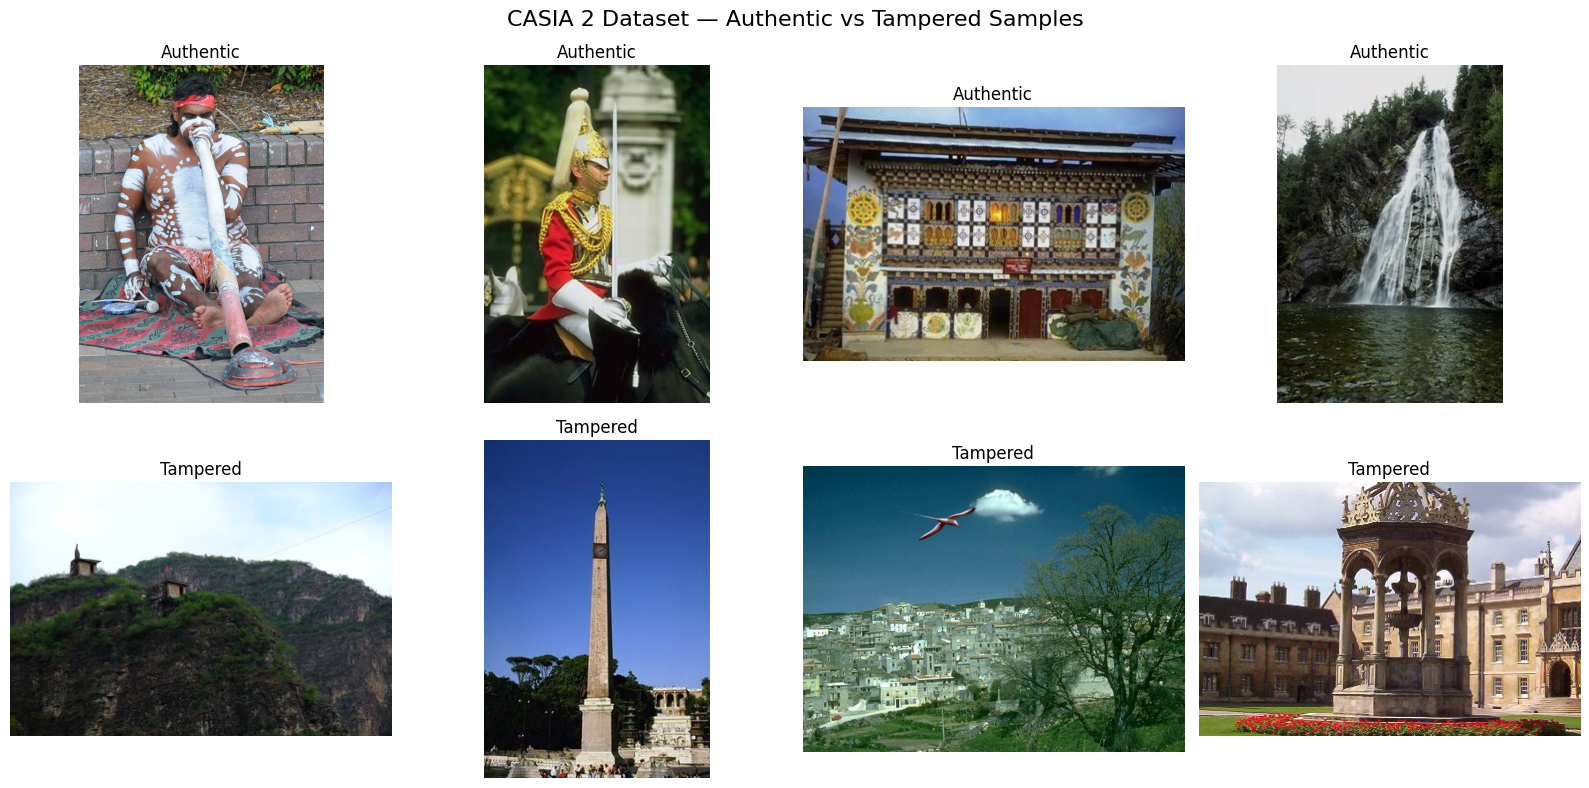

IMAGE DIMENSION CHECK

Authentic:
Au_cha_10179.jpg                                   (506, 700) | RGB
Au_cha_30204.jpg                                   (256, 384) | RGB
Au_arc_30834.jpg                                   (384, 256) | RGB
Au_nat_30135.jpg                                   (256, 384) | RGB

Tampered:
Tp_S_NNN_S_N_nat10107_nat10107_11348.jpg           (384, 256) | RGB
Tp_D_NRN_S_N_arc00013_sec00045_11700.jpg           (256, 384) | RGB
Tp_D_NRN_S_N_nat10158_ani00005_12026.jpg           (640, 480) | RGB
Tp_S_NNN_S_N_arc00034_arc00034_01090.tif           (384, 256) | RGB


In [6]:
# ============================================================
# Cell 6: Visual Inspection of CASIA 2 Images
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# ------------------------------------------------------------
# Select random images
# ------------------------------------------------------------

random.seed(SEED)

sample_authentic = random.sample(train_authentic, 4)
sample_tampered = random.sample(test_tampered, 4)

# ------------------------------------------------------------
# Display authentic images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, image_path in enumerate(sample_authentic):
    image = Image.open(image_path).convert("RGB")

    axes[0, i].imshow(image)
    axes[0, i].set_title("Authentic")
    axes[0, i].axis("off")

# ------------------------------------------------------------
# Display tampered images
# ------------------------------------------------------------

for i, image_path in enumerate(sample_tampered):
    image = Image.open(image_path).convert("RGB")

    axes[1, i].imshow(image)
    axes[1, i].set_title("Tampered")
    axes[1, i].axis("off")

plt.suptitle(
    "CASIA 2 Dataset — Authentic vs Tampered Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Inspect image dimensions
# ------------------------------------------------------------

print("=" * 60)
print("IMAGE DIMENSION CHECK")
print("=" * 60)

for category, samples in [
    ("Authentic", sample_authentic),
    ("Tampered", sample_tampered)
]:
    print(f"\n{category}:")

    for path in samples:
        with Image.open(path) as img:
            print(
                f"{os.path.basename(path):50s} "
                f"{img.size} | {img.mode}"
            )

# Cell 7: Transformer V2 Configuration

This cell defines the main settings of the Transformer model.

The input images are resized to 128 × 128 pixels and divided into 16 × 16 patches.

This produces 64 image patches. Each patch is converted into a 256-dimensional embedding.

The Transformer uses multiple attention heads and encoder/decoder blocks to learn relationships between different image patches.

These settings control the size and complexity of the Transformer model.

In [7]:
# ============================================================
# Cell 7: Transformer Configuration
# ============================================================

# Image configuration
IMAGE_SIZE = 128
CHANNELS = 3

# Patch configuration
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

# Transformer configuration
EMBED_DIM = 256
NUM_HEADS = 8
NUM_ENCODER_LAYERS = 4

# Feed-forward network
FF_DIM = 512

# Regularization
DROPOUT = 0.1

# Training configuration
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

print("=" * 60)
print("TRANSFORMER CONFIGURATION")
print("=" * 60)

print(f"\nImage size          : {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Channels            : {CHANNELS}")
print(f"Patch size          : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Number of patches   : {NUM_PATCHES}")
print(f"Embedding dimension : {EMBED_DIM}")
print(f"Attention heads     : {NUM_HEADS}")
print(f"Encoder layers      : {NUM_ENCODER_LAYERS}")
print(f"Feed-forward dim    : {FF_DIM}")
print(f"Dropout             : {DROPOUT}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Weight decay        : {WEIGHT_DECAY}")

print("\n✓ Transformer configuration ready.")

TRANSFORMER CONFIGURATION

Image size          : 128 × 128
Channels            : 3
Patch size          : 16 × 16
Number of patches   : 64
Embedding dimension : 256
Attention heads     : 8
Encoder layers      : 4
Feed-forward dim    : 512
Dropout             : 0.1
Batch size          : 64
Learning rate       : 0.0001
Weight decay        : 1e-05

✓ Transformer configuration ready.


# Cell 8: Image Preprocessing & Dataset Class

This cell prepares the CASIA v2.0 images for the Transformer model.

The images are:

- Resized to 128 × 128 pixels
- Converted to RGB format
- Converted into PyTorch tensors
- Normalized to a pixel range of 0 to 1

A custom dataset class is used to load the images and their labels.

The same preprocessing is applied to training, validation, and testing images.

In [8]:
# ============================================================
# Cell 8: Image Preprocessing & Dataset Class
# ============================================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------
# Image preprocessing
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

class ForensicImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_path = self.dataframe.iloc[index]["path"]
        label = int(self.dataframe.iloc[index]["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = ForensicImageDataset(
    train_df,
    transform=transform
)

val_dataset = ForensicImageDataset(
    val_df,
    transform=transform
)

test_dataset = ForensicImageDataset(
    test_df,
    transform=transform
)

# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 60)
print("DATASET & DATALOADER SETUP")
print("=" * 60)

print(f"\nTraining samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test samples       : {len(test_dataset)}")

# Load one batch
images, labels = next(iter(train_loader))

print("\nBatch shape        :", images.shape)
print("Labels shape       :", labels.shape)
print("Pixel range        :", images.min().item(), "to", images.max().item())

print("\n✓ Data pipeline ready.")

DATASET & DATALOADER SETUP

Training samples   : 5243
Validation samples : 1123
Test samples       : 6248

Batch shape        : torch.Size([64, 3, 128, 128])
Labels shape       : torch.Size([64])
Pixel range        : 0.0 to 1.0

✓ Data pipeline ready.


# Cell 9: Image-to-Patch Embedding

A Transformer does not directly process an image as a complete 2D object.

In this step, each 128 × 128 image is divided into smaller 16 × 16 patches.

This creates:

- 8 × 8 patches
- 64 patches in total
- 3 RGB channels per patch

Each patch is converted into a 256-dimensional embedding using a convolutional projection.

The resulting patch sequence is given to the Transformer encoder.

In [9]:
# ============================================================
# Cell 9: Image-to-Patch Embedding
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(
        self,
        image_size=128,
        patch_size=16,
        in_channels=3,
        embed_dim=256
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size

        self.num_patches = (
            image_size // patch_size
        ) ** 2

        # Convert each image patch into an embedding
        self.projection = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        # x:
        # [batch, 3, 128, 128]

        x = self.projection(x)

        # [batch, 256, 8, 8]

        x = x.flatten(2)

        # [batch, 256, 64]

        x = x.transpose(1, 2)

        # [batch, 64, 256]

        return x


# ------------------------------------------------------------
# Create patch embedding layer
# ------------------------------------------------------------

patch_embedding = PatchEmbedding(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    embed_dim=EMBED_DIM
).to(device)


# ------------------------------------------------------------
# Test with one batch
# ------------------------------------------------------------

with torch.no_grad():

    sample_embeddings = patch_embedding(
        images.to(device)
    )

print("=" * 60)
print("PATCH EMBEDDING TEST")
print("=" * 60)

print("\nInput image shape      :", images.shape)
print("Patch embedding shape  :", sample_embeddings.shape)
print("Number of patches      :", patch_embedding.num_patches)
print("Embedding dimension    :", EMBED_DIM)

print("\n✓ Patch embedding working correctly.")

PATCH EMBEDDING TEST

Input image shape      : torch.Size([64, 3, 128, 128])
Patch embedding shape  : torch.Size([64, 64, 256])
Number of patches      : 64
Embedding dimension    : 256

✓ Patch embedding working correctly.


# Cell 10: Transformer Encoder Block

This cell defines one Transformer encoder block.

The block uses:

- Layer Normalization
- Multi-Head Self-Attention
- Feed-Forward Network
- Dropout
- Residual connections

Self-attention allows the model to learn relationships between different image patches.

The output keeps the same shape as the input patch sequence, so multiple Transformer blocks can be stacked together.

In [41]:
# ============================================================
# Cell 11: Transformer Encoder Block
# ============================================================

class TransformerEncoderBlock(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        ff_dim=512,
        dropout=0.1
    ):
        super().__init__()

        # Layer Normalization before attention
        self.norm1 = nn.LayerNorm(embed_dim)

        # Multi-Head Self-Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Layer Normalization before FFN
        self.norm2 = nn.LayerNorm(embed_dim)

        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim)
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # ----------------------------------------------------
        # Multi-Head Self-Attention
        # ----------------------------------------------------

        normalized_x = self.norm1(x)

        attention_output, attention_weights = self.attention(
            normalized_x,
            normalized_x,
            normalized_x,
            need_weights=True
        )

        # Residual connection
        x = x + self.dropout(attention_output)

        # ----------------------------------------------------
        # Feed-Forward Network
        # ----------------------------------------------------

        normalized_x = self.norm2(x)

        ffn_output = self.ffn(normalized_x)

        # Residual connection
        x = x + self.dropout(ffn_output)

        return x, attention_weights


# ------------------------------------------------------------
# Create one encoder block
# ------------------------------------------------------------

encoder_block = TransformerEncoderBlock(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    dropout=DROPOUT
).to(device)


# ------------------------------------------------------------
# Test encoder block
# ------------------------------------------------------------

with torch.no_grad():

    encoder_output, attention_weights = encoder_block(
        positioned_embeddings
    )

print("=" * 60)
print("TRANSFORMER ENCODER BLOCK TEST")
print("=" * 60)

print("\nInput shape            :", positioned_embeddings.shape)
print("Encoder output shape   :", encoder_output.shape)
print("Attention shape        :", attention_weights.shape)

print("\n✓ Transformer encoder block working correctly.")

TRANSFORMER ENCODER BLOCK TEST

Input shape            : torch.Size([64, 64, 256])
Encoder output shape   : torch.Size([64, 64, 256])
Attention shape        : torch.Size([64, 64, 64])

✓ Transformer encoder block working correctly.


# Cell 11: Transformer Encoder

The Transformer encoder processes the sequence of image patch embeddings.

It contains 4 Transformer encoder blocks.

Each block uses self-attention to learn relationships between different image patches.

The encoder keeps the same number of patch tokens while improving their learned representations.

The output is used by the reconstruction decoder and for generating the global image representation.

In [12]:
# ============================================================
# Cell 12: Transformer Encoder
# ============================================================

class TransformerEncoder(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        ff_dim=512,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        # Stack multiple Transformer encoder blocks
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        # Final normalization
        self.final_norm = nn.LayerNorm(embed_dim)

    def forward(self, x):

        attention_maps = []

        for layer in self.layers:

            x, attention_weights = layer(x)

            attention_maps.append(attention_weights)

        x = self.final_norm(x)

        return x, attention_maps


# ------------------------------------------------------------
# Create full Transformer encoder
# ------------------------------------------------------------

transformer_encoder = TransformerEncoder(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_ENCODER_LAYERS,
    dropout=DROPOUT
).to(device)


# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

with torch.no_grad():

    encoded_features, attention_maps = transformer_encoder(
        positioned_embeddings
    )

print("=" * 60)
print("TRANSFORMER ENCODER TEST")
print("=" * 60)

print("\nInput shape           :", positioned_embeddings.shape)
print("Encoded output shape  :", encoded_features.shape)
print("Number of layers      :", len(attention_maps))

for i, attention in enumerate(attention_maps):
    print(f"Layer {i + 1} attention shape :", attention.shape)

print("\n✓ Full Transformer encoder working correctly.")

TRANSFORMER ENCODER TEST

Input shape           : torch.Size([64, 64, 256])
Encoded output shape  : torch.Size([64, 64, 256])
Number of layers      : 4
Layer 1 attention shape : torch.Size([64, 64, 64])
Layer 2 attention shape : torch.Size([64, 64, 64])
Layer 3 attention shape : torch.Size([64, 64, 64])
Layer 4 attention shape : torch.Size([64, 64, 64])

✓ Full Transformer encoder working correctly.


# Cell 12: Latent Image Representation

This cell creates a compact representation of the image from the Transformer encoder output.

The 64 encoded image patches are combined to create a 256-dimensional global representation.

This representation can be used for:

- Compact image features
- Image-level analysis
- Comparing learned representations

In Transformer V2, this global representation is kept for analysis, while the complete patch-token sequence is preserved separately for image reconstruction.

In [13]:
# ============================================================
# Cell 13: Latent Image Representation
# ============================================================

class ImageRepresentation(nn.Module):

    def __init__(self, embed_dim=256):
        super().__init__()

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):

        # x:
        # [batch, 64, 256]

        # Global representation from all image patches
        latent = x.mean(dim=1)

        # Normalize latent representation
        latent = self.norm(latent)

        # latent:
        # [batch, 256]

        return latent


# ------------------------------------------------------------
# Create representation module
# ------------------------------------------------------------

image_representation = ImageRepresentation(
    embed_dim=EMBED_DIM
).to(device)


# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

with torch.no_grad():

    latent_representation = image_representation(
        encoded_features
    )

print("=" * 60)
print("LATENT IMAGE REPRESENTATION TEST")
print("=" * 60)

print("\nEncoder output shape :", encoded_features.shape)
print("Latent shape         :", latent_representation.shape)

print(
    "\nExpected latent size :",
    f"[batch, {EMBED_DIM}]"
)

print("\n✓ Latent image representation working correctly.")

LATENT IMAGE REPRESENTATION TEST

Encoder output shape : torch.Size([64, 64, 256])
Latent shape         : torch.Size([64, 256])

Expected latent size : [batch, 256]

✓ Latent image representation working correctly.


# Cell 13: Transformer V2 Decoder

The Transformer decoder converts the encoded image patch tokens back into image patches.

Unlike the earlier version, the V2 decoder receives all encoded patch tokens directly.

This preserves spatial information from the original image and avoids compressing the entire image into a single vector before reconstruction.

The decoder:

1. Receives 64 encoded patch tokens
2. Adds decoder positional information
3. Processes the tokens using Transformer blocks
4. Converts each token into a 16 × 16 RGB patch
5. Combines the patches to reconstruct the 128 × 128 image

In [14]:
# ============================================================
# Cell 14: Transformer Decoder
# ============================================================

class TransformerDecoder(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        ff_dim=512,
        num_layers=2,
        num_patches=64,
        patch_size=16,
        output_channels=3,
        dropout=0.1
    ):
        super().__init__()

        self.num_patches = num_patches
        self.patch_size = patch_size
        self.output_channels = output_channels

        # Expand global latent vector into patch tokens
        self.latent_to_tokens = nn.Linear(
            embed_dim,
            num_patches * embed_dim
        )

        # Learnable positional information for decoder tokens
        self.position_embedding = nn.Parameter(
            torch.zeros(1, num_patches, embed_dim)
        )

        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02
        )

        # Transformer decoder blocks
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

        # Convert each token into an RGB image patch
        self.patch_projection = nn.Linear(
            embed_dim,
            patch_size * patch_size * output_channels
        )

    def forward(self, latent):

        # ----------------------------------------------------
        # Latent → patch tokens
        # ----------------------------------------------------

        x = self.latent_to_tokens(latent)

        x = x.view(
            latent.size(0),
            self.num_patches,
            -1
        )

        # Add positional information
        x = x + self.position_embedding

        # ----------------------------------------------------
        # Transformer processing
        # ----------------------------------------------------

        for layer in self.layers:

            x, _ = layer(x)

        x = self.final_norm(x)

        # ----------------------------------------------------
        # Tokens → image patches
        # ----------------------------------------------------

        patches = self.patch_projection(x)

        patches = patches.view(
            latent.size(0),
            self.num_patches,
            self.output_channels,
            self.patch_size,
            self.patch_size
        )

        # ----------------------------------------------------
        # Reconstruct 2D image
        # ----------------------------------------------------

        patches_per_side = IMAGE_SIZE // self.patch_size

        patches = patches.view(
            latent.size(0),
            patches_per_side,
            patches_per_side,
            self.output_channels,
            self.patch_size,
            self.patch_size
        )

        # Rearrange patches into image
        image = patches.permute(
            0, 3, 1, 4, 2, 5
        )

        image = image.contiguous().view(
            latent.size(0),
            self.output_channels,
            IMAGE_SIZE,
            IMAGE_SIZE
        )

        # Pixel values between 0 and 1
        image = torch.sigmoid(image)

        return image


# ------------------------------------------------------------
# Create decoder
# ------------------------------------------------------------

transformer_decoder = TransformerDecoder(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=2,
    num_patches=NUM_PATCHES,
    patch_size=PATCH_SIZE,
    output_channels=CHANNELS,
    dropout=DROPOUT
).to(device)


# ------------------------------------------------------------
# Test decoder
# ------------------------------------------------------------

with torch.no_grad():

    reconstructed_images = transformer_decoder(
        latent_representation
    )

print("=" * 60)
print("TRANSFORMER DECODER TEST")
print("=" * 60)

print("\nLatent input shape       :", latent_representation.shape)
print("Reconstructed shape      :", reconstructed_images.shape)

print(
    "Reconstructed pixel range:",
    reconstructed_images.min().item(),
    "to",
    reconstructed_images.max().item()
)

print("\n✓ Transformer decoder working correctly.")

TRANSFORMER DECODER TEST

Latent input shape       : torch.Size([64, 256])
Reconstructed shape      : torch.Size([64, 3, 128, 128])
Reconstructed pixel range: 0.06491432338953018 to 0.9443220496177673

✓ Transformer decoder working correctly.


## Cell 15 — Transformer Forensic Autoencoder V2

This cell combines the patch embedding, positional encoding, Transformer encoder, global image representation, and Transformer-based decoder into one complete forensic model.

The V2 architecture preserves the complete sequence of encoded image patch tokens for reconstruction instead of relying only on a single global latent vector.

### V2 Architecture

Input Image (128 × 128 × 3)  
↓  
Patch Embedding  
↓  
64 Image Patches  
↓  
Positional Embedding  
↓  
4 Transformer Encoder Layers  
↓  
Encoded Patch Tokens (64 × 256)  
↓  
Global 256-D Representation for Analysis  
↓  
Transformer-Based Decoder using Full Patch Tokens  
↓  
Reconstructed Image (128 × 128 × 3)

The model also returns attention maps from the encoder for later interpretability and forensic analysis.

In [36]:
# ============================================================
# Cell 15: Improved Transformer Forensic Autoencoder V2
# ============================================================

class TransformerForensicAutoencoder(nn.Module):

    def __init__(
        self,
        image_size=128,
        patch_size=16,
        in_channels=3,
        embed_dim=256,
        num_heads=8,
        encoder_layers=4,
        decoder_layers=2,
        ff_dim=512,
        dropout=0.1
    ):
        super().__init__()

        # ----------------------------------------------------
        # Number of image patches
        # ----------------------------------------------------

        num_patches = (image_size // patch_size) ** 2

        self.num_patches = num_patches
        self.embed_dim = embed_dim

        # ----------------------------------------------------
        # PATCH EMBEDDING
        # ----------------------------------------------------

        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        # ----------------------------------------------------
        # POSITIONAL EMBEDDING
        # ----------------------------------------------------

        self.positional_embedding = PositionalEmbedding(
            num_patches=num_patches,
            embed_dim=embed_dim
        )

        # ----------------------------------------------------
        # TRANSFORMER ENCODER
        # ----------------------------------------------------

        self.transformer_encoder = TransformerEncoder(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_layers=encoder_layers,
            dropout=dropout
        )

        # ----------------------------------------------------
        # GLOBAL LATENT REPRESENTATION
        #
        # Used for analysis/reporting.
        # NOT used as the only reconstruction information.
        # ----------------------------------------------------

        self.image_representation = ImageRepresentation(
            embed_dim=embed_dim
        )

        # ----------------------------------------------------
        # IMPROVED TRANSFORMER DECODER
        #
        # IMPORTANT:
        # The decoder receives ALL 64 encoded patch tokens.
        #
        # This preserves spatial information and avoids the
        # severe 64-token → 1-vector bottleneck of V1.
        # ----------------------------------------------------

        self.decoder_position_embedding = nn.Parameter(
            torch.zeros(
                1,
                num_patches,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.decoder_position_embedding,
            std=0.02
        )

        self.transformer_decoder_layers = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(decoder_layers)
        ])

        self.decoder_norm = nn.LayerNorm(
            embed_dim
        )

        # ----------------------------------------------------
        # PATCH RECONSTRUCTION
        # Each token reconstructs one 16 × 16 RGB patch.
        # ----------------------------------------------------

        self.patch_projection = nn.Linear(
            embed_dim,
            patch_size * patch_size * in_channels
        )

        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        batch_size = x.size(0)

        # ----------------------------------------------------
        # 1. Image → patch tokens
        # ----------------------------------------------------

        x = self.patch_embedding(x)

        # Shape:
        # [B, 64, 256]

        # ----------------------------------------------------
        # 2. Add encoder positional information
        # ----------------------------------------------------

        x = self.positional_embedding(x)

        # ----------------------------------------------------
        # 3. Transformer encoder
        # ----------------------------------------------------

        encoded, attention_maps = self.transformer_encoder(x)

        # Shape:
        # [B, 64, 256]

        # ----------------------------------------------------
        # 4. Global 256-D latent representation
        #
        # Retained for evidence analysis.
        # ----------------------------------------------------

        latent = self.image_representation(encoded)

        # Shape:
        # [B, 256]

        # ----------------------------------------------------
        # 5. IMPORTANT:
        # Keep ALL encoded patch tokens for reconstruction.
        # ----------------------------------------------------

        decoder_tokens = (
            encoded +
            self.decoder_position_embedding
        )

        # ----------------------------------------------------
        # 6. Transformer decoder blocks
        # ----------------------------------------------------

        for layer in self.transformer_decoder_layers:

            decoder_tokens, _ = layer(
                decoder_tokens
            )

        decoder_tokens = self.decoder_norm(
            decoder_tokens
        )

        # Shape:
        # [B, 64, 256]

        # ----------------------------------------------------
        # 7. Convert each token into a 16×16 RGB patch
        # ----------------------------------------------------

        patches = self.patch_projection(
            decoder_tokens
        )

        # Shape:
        # [B, 64, 768]
        #
        # 768 = 16 × 16 × 3

        patches = patches.view(
            batch_size,
            self.num_patches,
            self.in_channels,
            self.patch_size,
            self.patch_size
        )

        # ----------------------------------------------------
        # 8. Arrange 64 patches into 8 × 8 grid
        # ----------------------------------------------------

        patches_per_side = (
            self.image_size // self.patch_size
        )

        patches = patches.view(
            batch_size,
            patches_per_side,
            patches_per_side,
            self.in_channels,
            self.patch_size,
            self.patch_size
        )

        # ----------------------------------------------------
        # 9. Reconstruct full image
        # ----------------------------------------------------

        reconstructed = patches.permute(
            0, 3, 1, 4, 2, 5
        ).contiguous()

        reconstructed = reconstructed.view(
            batch_size,
            self.in_channels,
            self.image_size,
            self.image_size
        )

        # ----------------------------------------------------
        # 10. Keep output in [0, 1]
        # ----------------------------------------------------

        reconstructed = torch.sigmoid(
            reconstructed
        )

        return (
            reconstructed,
            latent,
            attention_maps
        )


# ============================================================
# CREATE TRANSFORMER V2
# ============================================================

transformer_model = TransformerForensicAutoencoder(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=2,
    ff_dim=FF_DIM,
    dropout=DROPOUT
).to(device)


# ============================================================
# TEST MODEL
# ============================================================

transformer_model.eval()

with torch.no_grad():

    sample_images, sample_labels = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(device)

    reconstructed, latent, attention_maps = (
        transformer_model(sample_images)
    )


# ============================================================
# VERIFY
# ============================================================

print("=" * 65)
print("IMPROVED TRANSFORMER FORENSIC AUTOENCODER V2")
print("=" * 65)

print("\nInput image shape       :", sample_images.shape)
print("Encoded patch tokens    :",
      f"[{sample_images.shape[0]}, {NUM_PATCHES}, {EMBED_DIM}]")
print("Global latent           :", latent.shape)
print("Reconstructed image     :", reconstructed.shape)
print("Attention layers        :", len(attention_maps))

print("\nModel device            :",
      next(transformer_model.parameters()).device)

print("\nArchitecture improvement:")
print("✓ Encoder patch tokens are preserved.")
print("✓ Decoder receives all spatial patch tokens.")
print("✓ Global 256-D latent is retained for analysis.")
print("✓ Severe single-vector reconstruction bottleneck removed.")

print("\n✓ Transformer V2 forward pass successful.")

IMPROVED TRANSFORMER FORENSIC AUTOENCODER V2

Input image shape       : torch.Size([64, 3, 128, 128])
Encoded patch tokens    : [64, 64, 256]
Global latent           : torch.Size([64, 256])
Reconstructed image     : torch.Size([64, 3, 128, 128])
Attention layers        : 4

Model device            : cuda:0

Architecture improvement:
✓ Encoder patch tokens are preserved.
✓ Decoder receives all spatial patch tokens.
✓ Global 256-D latent is retained for analysis.
✓ Severe single-vector reconstruction bottleneck removed.

✓ Transformer V2 forward pass successful.


## Cell 16 — Transformer V2 Parameter Count

This cell calculates the total number of parameters in the Transformer V2 model.

Parameter count helps measure the size and complexity of the model.

The cell reports:
- Total parameters
- Trainable parameters
- Approximate model size

A larger parameter count generally means a more complex model, but it may also require more memory and computation.

In [37]:
# ============================================================
# Cell 16: Transformer V2 Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in transformer_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in transformer_model.parameters()
    if p.requires_grad
)

model_size_mb = (
    total_params * 4
) / (1024 ** 2)

print("=" * 60)
print("TRANSFORMER V2 MODEL PARAMETERS")
print("=" * 60)

print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Approx. model size   : {model_size_mb:.2f} MB")

print("\n✓ Parameter count verified.")
print("✓ Transformer V2 is ready for training.")

TRANSFORMER V2 MODEL PARAMETERS

Total parameters     : 3,591,168
Trainable parameters : 3,591,168
Approx. model size   : 13.70 MB

✓ Parameter count verified.
✓ Transformer V2 is ready for training.


In [38]:
# ============================================================
# Cell 17: Transformer V2 Loss, Optimizer and Scheduler
# ============================================================

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    transformer_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("=" * 60)
print("TRANSFORMER V2 TRAINING CONFIGURATION")
print("=" * 60)

print(f"\nLoss function   : MSELoss")
print(f"Optimizer       : AdamW")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Weight decay    : {WEIGHT_DECAY}")
print(f"Scheduler       : ReduceLROnPlateau")
print(f"LR reduction    : ×0.5")
print(f"Scheduler patience: 5 epochs")
print(f"Minimum LR      : 1e-6")

print("\n✓ V2 loss configured.")
print("✓ V2 optimizer configured.")
print("✓ V2 learning-rate scheduler configured.")

TRANSFORMER V2 TRAINING CONFIGURATION

Loss function   : MSELoss
Optimizer       : AdamW
Learning rate   : 0.0001
Weight decay    : 1e-05
Scheduler       : ReduceLROnPlateau
LR reduction    : ×0.5
Scheduler patience: 5 epochs
Minimum LR      : 1e-6

✓ V2 loss configured.
✓ V2 optimizer configured.
✓ V2 learning-rate scheduler configured.


## Cell 18 — Transformer V2 Smoke Test

This cell performs a quick test before full training.

It verifies that:
- The model can process a training batch.
- The reconstructed output has the correct shape.
- The reconstruction loss can be calculated.
- The forward and backward passes work correctly.
- The model can run successfully on the selected device.

This helps detect implementation or tensor-shape errors before starting the full training process.

In [39]:
# ============================================================
# Cell 18: Transformer V2 Smoke Test
# ============================================================

import time

transformer_model.train()

smoke_losses = []

start_time = time.time()

for batch_idx, (batch_images, batch_labels) in enumerate(train_loader):

    # Only test 10 batches
    if batch_idx >= 10:
        break

    batch_images = batch_images.to(
        device,
        non_blocking=True
    )

    # Clear gradients
    optimizer.zero_grad(set_to_none=True)

    # Forward pass
    reconstructed, latent, attention_maps = (
        transformer_model(batch_images)
    )

    # Reconstruction loss
    loss = criterion(
        reconstructed,
        batch_images
    )

    # Backpropagation
    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(
        transformer_model.parameters(),
        max_norm=1.0
    )

    # Optimizer update
    optimizer.step()

    smoke_losses.append(
        loss.item()
    )

elapsed_time = time.time() - start_time

average_smoke_loss = np.mean(
    smoke_losses
)

print("=" * 60)
print("TRANSFORMER V2 SMOKE TEST")
print("=" * 60)

print(f"\nBatches tested    : {len(smoke_losses)}")
print(f"Average MSE       : {average_smoke_loss:.6f}")
print(f"Time              : {elapsed_time:.2f} seconds")

print("\n✓ Forward pass successful.")
print("✓ Reconstruction loss successful.")
print("✓ Backpropagation successful.")
print("✓ Gradient clipping successful.")
print("✓ Optimizer update successful.")

print("\n✓ Transformer V2 smoke test completed.")

TRANSFORMER V2 SMOKE TEST

Batches tested    : 10
Average MSE       : 0.084471
Time              : 3.55 seconds

✓ Forward pass successful.
✓ Reconstruction loss successful.
✓ Backpropagation successful.
✓ Gradient clipping successful.
✓ Optimizer update successful.

✓ Transformer V2 smoke test completed.


## Cell 19 — Full Transformer V2 Training

This cell trains the complete Transformer V2 forensic autoencoder using authentic images.

The model learns the reconstruction patterns of authentic images and minimizes the reconstruction error between the input and reconstructed image.

### Training Configuration

- Training data: Authentic images only
- Validation data: Authentic images only
- Loss function: Mean Squared Error (MSE)
- Optimizer: AdamW
- Learning rate: 0.0001
- Weight decay: 0.00001
- Batch size: 64
- Maximum epochs: 50
- Learning-rate scheduler: ReduceLROnPlateau

The best model is selected based on the lowest validation MSE and saved as a checkpoint.

The trained reconstruction error is later used as an anomaly score for forensic screening.

In [40]:
# ============================================================
# Cell 19: Full Transformer V2 Training
# ============================================================

import time

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 50

V2_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_transformer_forensic_v2.pth"
)

train_losses = []
val_losses = []
learning_rates = []

best_val_loss = float("inf")
best_epoch = 0

training_start_time = time.time()

print("=" * 65)
print("TRANSFORMER V2 FULL TRAINING")
print("=" * 65)

print(f"\nEpochs       : {NUM_EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Device       : {device}")

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    transformer_model.train()

    running_train_loss = 0.0
    train_batches = 0

    for batch_images, batch_labels in train_loader:

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        reconstructed, latent, attention_maps = (
            transformer_model(batch_images)
        )

        loss = criterion(
            reconstructed,
            batch_images
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += loss.item()
        train_batches += 1

    train_loss = (
        running_train_loss / train_batches
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    transformer_model.eval()

    running_val_loss = 0.0
    val_batches = 0

    with torch.no_grad():

        for batch_images, batch_labels in val_loader:

            batch_images = batch_images.to(
                device,
                non_blocking=True
            )

            reconstructed, latent, attention_maps = (
                transformer_model(batch_images)
            )

            loss = criterion(
                reconstructed,
                batch_images
            )

            running_val_loss += loss.item()
            val_batches += 1

    val_loss = (
        running_val_loss / val_batches
    )

    # --------------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------------

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    learning_rates.append(current_lr)

    # --------------------------------------------------------
    # Save best checkpoint
    # --------------------------------------------------------

    is_best = val_loss < best_val_loss

    if is_best:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": transformer_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "learning_rate": current_lr,
                "architecture": "Transformer Forensic Autoencoder V2"
            },
            V2_CHECKPOINT_PATH
        )

    # --------------------------------------------------------
    # Progress output
    # --------------------------------------------------------

    marker = " ★ BEST" if is_best else ""

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train MSE: {train_loss:.6f} | "
        f"Val MSE: {val_loss:.6f} | "
        f"LR: {current_lr:.2e}"
        f"{marker}"
    )


# ============================================================
# TRAINING COMPLETED
# ============================================================

training_time = (
    time.time() - training_start_time
)

# Restore best V2 checkpoint
best_checkpoint = torch.load(
    V2_CHECKPOINT_PATH,
    map_location=device
)

transformer_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

transformer_model.eval()

print("\n" + "=" * 65)
print("TRANSFORMER V2 TRAINING COMPLETED")
print("=" * 65)

print(f"\nBest epoch       : {best_epoch}")
print(f"Best validation  : {best_val_loss:.6f}")
print(f"Training time    : {training_time / 60:.2f} minutes")

print("\nBest checkpoint:")
print(V2_CHECKPOINT_PATH)

print("\n✓ Best Transformer V2 model restored.")
print("✓ V1 checkpoint remains untouched.")

TRANSFORMER V2 FULL TRAINING

Epochs       : 50
Batch size   : 64
Learning rate: 0.0001
Device       : cuda
Epoch [01/50] | Train MSE: 0.042830 | Val MSE: 0.023442 | LR: 1.00e-04 ★ BEST
Epoch [02/50] | Train MSE: 0.020314 | Val MSE: 0.015306 | LR: 1.00e-04 ★ BEST
Epoch [03/50] | Train MSE: 0.015075 | Val MSE: 0.012553 | LR: 1.00e-04 ★ BEST
Epoch [04/50] | Train MSE: 0.012998 | Val MSE: 0.010729 | LR: 1.00e-04 ★ BEST
Epoch [05/50] | Train MSE: 0.011265 | Val MSE: 0.009361 | LR: 1.00e-04 ★ BEST
Epoch [06/50] | Train MSE: 0.010040 | Val MSE: 0.008465 | LR: 1.00e-04 ★ BEST
Epoch [07/50] | Train MSE: 0.009210 | Val MSE: 0.007797 | LR: 1.00e-04 ★ BEST
Epoch [08/50] | Train MSE: 0.008543 | Val MSE: 0.007180 | LR: 1.00e-04 ★ BEST
Epoch [09/50] | Train MSE: 0.007962 | Val MSE: 0.006779 | LR: 1.00e-04 ★ BEST
Epoch [10/50] | Train MSE: 0.007499 | Val MSE: 0.006303 | LR: 1.00e-04 ★ BEST
Epoch [11/50] | Train MSE: 0.007088 | Val MSE: 0.006794 | LR: 1.00e-04
Epoch [12/50] | Train MSE: 0.006782 | Val

## Cell 20 — Training & Validation Loss Curves

This cell visualizes the training and validation MSE across all epochs.

The curves help evaluate how the Transformer V2 model learns over time and whether the model shows signs of overfitting.

A decreasing validation loss indicates improved reconstruction performance on unseen authentic images.

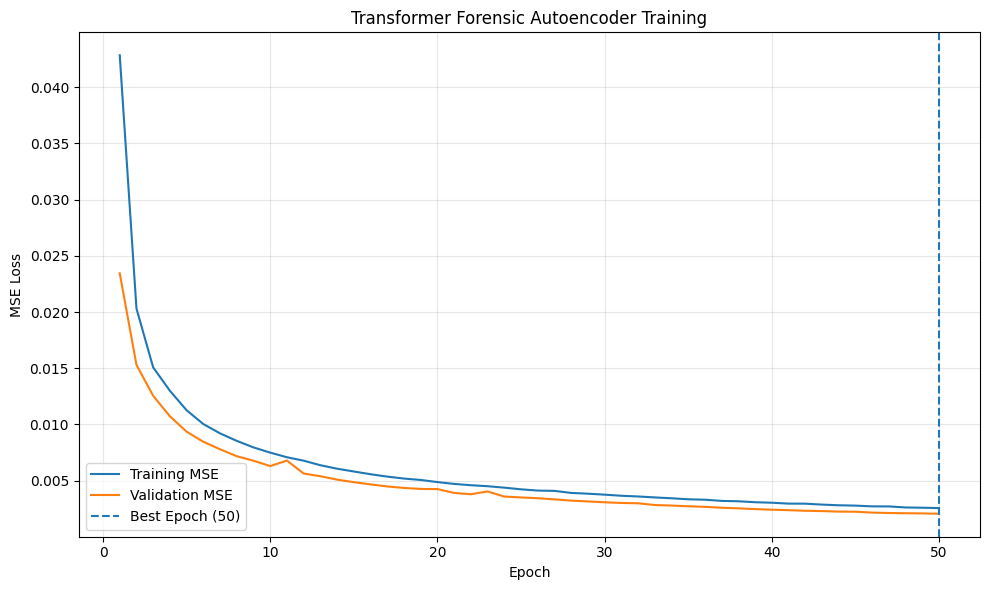

TRAINING CURVE SUMMARY

Total epochs trained : 50
Best epoch           : 50
Best validation MSE  : 0.002060
Final training MSE   : 0.002569
Final validation MSE : 0.002060


In [42]:
# ============================================================
# Cell 20: Training & Validation Loss Curves
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="Training MSE"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    label="Validation MSE"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Forensic Autoencoder Training")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 60)
print("TRAINING CURVE SUMMARY")
print("=" * 60)

print(f"\nTotal epochs trained : {len(train_losses)}")
print(f"Best epoch           : {best_epoch}")
print(f"Best validation MSE  : {best_val_loss:.6f}")
print(f"Final training MSE   : {train_losses[-1]:.6f}")
print(f"Final validation MSE : {val_losses[-1]:.6f}")

## Cell 21 — Load and Verify Transformer V2 Checkpoint

This cell loads the best Transformer V2 model saved during training.

The checkpoint contains the trained model parameters and training information.

After loading, the model is switched to evaluation mode so it can be used for reconstruction quality testing, anomaly detection, attention visualization, and forensic image analysis.

In [44]:
# ============================================================
# Cell 21: Load and Verify Transformer V2 Checkpoint
# ============================================================

V2_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_transformer_forensic_v2.pth"
)

print("=" * 65)
print("TRANSFORMER V2 CHECKPOINT VERIFICATION")
print("=" * 65)

# ------------------------------------------------------------
# Check checkpoint file
# ------------------------------------------------------------

if not os.path.exists(V2_CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"V2 checkpoint not found:\n{V2_CHECKPOINT_PATH}"
    )

print("\nCheckpoint found:")
print(V2_CHECKPOINT_PATH)

# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    V2_CHECKPOINT_PATH,
    map_location=device
)

# ------------------------------------------------------------
# Restore model
# ------------------------------------------------------------

transformer_model.load_state_dict(
    checkpoint["model_state_dict"]
)

transformer_model = transformer_model.to(device)
transformer_model.eval()

# ------------------------------------------------------------
# Display checkpoint information
# ------------------------------------------------------------

print("\nSaved epoch       :",
      checkpoint["epoch"])

print("Training MSE       :",
      f"{checkpoint['train_loss']:.6f}")

print("Validation MSE     :",
      f"{checkpoint['val_loss']:.6f}")

print("Learning rate      :",
      f"{checkpoint['learning_rate']:.2e}")

print("Architecture       :",
      checkpoint["architecture"])

print("Device             :",
      device)

print("\n✓ V2 checkpoint loaded successfully.")
print("✓ Correct model weights restored.")
print("✓ Model is ready for forensic evaluation.")

TRANSFORMER V2 CHECKPOINT VERIFICATION

Checkpoint found:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/checkpoints/best_transformer_forensic_v2.pth

Saved epoch       : 50
Training MSE       : 0.002569
Validation MSE     : 0.002060
Learning rate      : 1.00e-04
Architecture       : Transformer Forensic Autoencoder V2
Device             : cuda

✓ V2 checkpoint loaded successfully.
✓ Correct model weights restored.
✓ Model is ready for forensic evaluation.


# Cell 22: Transformer V2 Reconstruction Quality

This cell evaluates how well the Transformer V2 reconstructs authentic images.

Two image-quality measures are used:

- **PSNR:** Measures pixel-level reconstruction quality. Higher values indicate better reconstruction.
- **SSIM:** Measures structural similarity between the original and reconstructed image. Values closer to 1 indicate stronger similarity.

The evaluation is performed on the authentic validation images.

In [46]:
# ============================================================
# Cell 22: Transformer V2 Reconstruction Quality
# ============================================================

import numpy as np
import torch
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

transformer_model.eval()

psnr_scores = []
ssim_scores = []

with torch.no_grad():

    for batch_images, _ in val_loader:

        batch_images = batch_images.to(device)

        # V2 reconstruction
        reconstructed, _, _ = transformer_model(
            batch_images
        )

        # Move to CPU
        original_np = (
            batch_images
            .cpu()
            .numpy()
        )

        reconstructed_np = (
            reconstructed
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # Calculate PSNR and SSIM per image
        # ----------------------------------------------------

        for i in range(
            original_np.shape[0]
        ):

            original = np.transpose(
                original_np[i],
                (1, 2, 0)
            )

            reconstruction = np.transpose(
                reconstructed_np[i],
                (1, 2, 0)
            )

            psnr = peak_signal_noise_ratio(
                original,
                reconstruction,
                data_range=1.0
            )

            ssim = structural_similarity(
                original,
                reconstruction,
                data_range=1.0,
                channel_axis=2
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

psnr_scores = np.array(psnr_scores)
ssim_scores = np.array(ssim_scores)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 RECONSTRUCTION QUALITY")
print("=" * 65)

print("\nValidation images :", len(psnr_scores))

print("\nPSNR:")
print(
    f"Mean    : {psnr_scores.mean():.4f} dB"
)
print(
    f"Median  : {np.median(psnr_scores):.4f} dB"
)
print(
    f"Minimum : {psnr_scores.min():.4f} dB"
)
print(
    f"Maximum : {psnr_scores.max():.4f} dB"
)

print("\nSSIM:")
print(
    f"Mean    : {ssim_scores.mean():.4f}"
)
print(
    f"Median  : {np.median(ssim_scores):.4f}"
)
print(
    f"Minimum : {ssim_scores.min():.4f}"
)
print(
    f"Maximum : {ssim_scores.max():.4f}"
)

print("\n" + "-" * 65)

print("Interpretation:")
print("Higher PSNR → lower reconstruction error.")
print("Higher SSIM → greater structural similarity.")

print("\n✓ V2 reconstruction quality evaluation completed.")

TRANSFORMER V2 RECONSTRUCTION QUALITY

Validation images : 1123

PSNR:
Mean    : 27.5793 dB
Median  : 27.3844 dB
Minimum : 20.0404 dB
Maximum : 39.2715 dB

SSIM:
Mean    : 0.8498
Median  : 0.8540
Minimum : 0.6012
Maximum : 0.9611

-----------------------------------------------------------------
Interpretation:
Higher PSNR → lower reconstruction error.
Higher SSIM → greater structural similarity.

✓ V2 reconstruction quality evaluation completed.


# Cell 23: Transformer V2 Per-Image Reconstruction Errors

This cell calculates the reconstruction error for every authentic validation image.

The reconstruction error is measured using Mean Squared Error (MSE).

A lower MSE means the image is reconstructed more closely.

A higher MSE means the image is reconstructed less accurately.

These individual reconstruction errors will later be used to establish an anomaly threshold for forensic analysis.

In [47]:
# ============================================================
# Cell 23: Transformer V2 Per-Image Reconstruction Errors
# ============================================================

transformer_model.eval()

validation_errors_v2 = []
validation_labels_v2 = []
validation_paths_v2 = []

# ------------------------------------------------------------
# Calculate error for every validation image
# ------------------------------------------------------------

with torch.no_grad():

    for batch_images, batch_labels in val_loader:

        batch_images = batch_images.to(device)

        # V2 reconstruction
        reconstructed, _, _ = transformer_model(
            batch_images
        )

        # Per-image MSE
        batch_errors = torch.mean(
            (reconstructed - batch_images) ** 2,
            dim=(1, 2, 3)
        )

        validation_errors_v2.extend(
            batch_errors.cpu().numpy()
        )

        validation_labels_v2.extend(
            batch_labels.numpy()
        )

# ------------------------------------------------------------
# Get validation image paths
# ------------------------------------------------------------

validation_paths_v2 = val_df["path"].tolist()

# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

validation_errors_v2 = np.array(
    validation_errors_v2
)

validation_labels_v2 = np.array(
    validation_labels_v2
)

validation_paths_v2 = np.array(
    validation_paths_v2
)

# ------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 VALIDATION RECONSTRUCTION ERRORS")
print("=" * 65)

print(
    f"\nValidation images : "
    f"{len(validation_errors_v2)}"
)

print(
    f"\nMean MSE          : "
    f"{validation_errors_v2.mean():.6f}"
)

print(
    f"Median MSE        : "
    f"{np.median(validation_errors_v2):.6f}"
)

print(
    f"Std MSE           : "
    f"{validation_errors_v2.std():.6f}"
)

print(
    f"\nMinimum MSE       : "
    f"{validation_errors_v2.min():.6f}"
)

print(
    f"Maximum MSE       : "
    f"{validation_errors_v2.max():.6f}"
)

print("\n✓ Per-image V2 reconstruction errors calculated.")

TRANSFORMER V2 VALIDATION RECONSTRUCTION ERRORS

Validation images : 1123

Mean MSE          : 0.002061
Median MSE        : 0.001826
Std MSE           : 0.001247

Minimum MSE       : 0.000118
Maximum MSE       : 0.009907

✓ Per-image V2 reconstruction errors calculated.


# Cell 24: Transformer V2 Reconstruction Error Distribution

This cell visualizes the reconstruction errors of authentic validation images.

The distribution shows how much reconstruction error is normally produced by authentic images.

Percentiles are calculated to understand the normal error range.

This information will be used in the next cell to select an anomaly threshold.

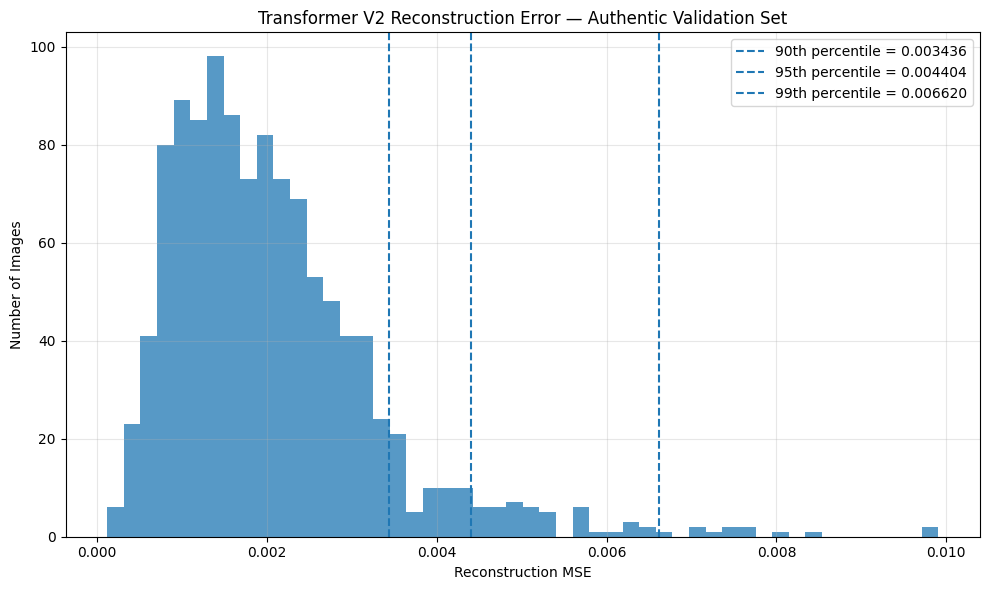

TRANSFORMER V2 RECONSTRUCTION ERROR DISTRIBUTION

Mean       : 0.002061
Median     : 0.001826
90th %ile  : 0.003436
95th %ile  : 0.004404
99th %ile  : 0.006620
Maximum    : 0.009907

✓ V2 error distribution visualized.


In [48]:
# ============================================================
# Cell 24: Transformer V2 Reconstruction Error Distribution
# ============================================================

# ------------------------------------------------------------
# Calculate percentiles
# ------------------------------------------------------------

v2_p90 = np.percentile(
    validation_errors_v2,
    90
)

v2_p95 = np.percentile(
    validation_errors_v2,
    95
)

v2_p99 = np.percentile(
    validation_errors_v2,
    99
)

# ------------------------------------------------------------
# Plot distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    validation_errors_v2,
    bins=50,
    alpha=0.75
)

plt.axvline(
    v2_p90,
    linestyle="--",
    label=f"90th percentile = {v2_p90:.6f}"
)

plt.axvline(
    v2_p95,
    linestyle="--",
    label=f"95th percentile = {v2_p95:.6f}"
)

plt.axvline(
    v2_p99,
    linestyle="--",
    label=f"99th percentile = {v2_p99:.6f}"
)

plt.xlabel("Reconstruction MSE")
plt.ylabel("Number of Images")

plt.title(
    "Transformer V2 Reconstruction Error — Authentic Validation Set"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print statistics
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 RECONSTRUCTION ERROR DISTRIBUTION")
print("=" * 65)

print(
    f"\nMean       : {validation_errors_v2.mean():.6f}"
)

print(
    f"Median     : {np.median(validation_errors_v2):.6f}"
)

print(
    f"90th %ile  : {v2_p90:.6f}"
)

print(
    f"95th %ile  : {v2_p95:.6f}"
)

print(
    f"99th %ile  : {v2_p99:.6f}"
)

print(
    f"Maximum    : {validation_errors_v2.max():.6f}"
)

print("\n✓ V2 error distribution visualized.")

# Cell 25: Transformer V2 Anomaly Threshold

The anomaly threshold is calculated from authentic validation images.

The 95th percentile of the authentic reconstruction-error distribution is used as the initial threshold.

Images with reconstruction error above this value are marked as potential anomalies.

This does not prove that an image is tampered. It only indicates that the image should receive further forensic review.

In [50]:
# ============================================================
# Cell 25: Transformer V2 Anomaly Threshold
# ============================================================

# ------------------------------------------------------------
# Calculate V2 threshold
# ------------------------------------------------------------

ANOMALY_THRESHOLD_V2 = np.percentile(
    validation_errors_v2,
    95
)

V2_VALIDATION_MEAN = np.mean(
    validation_errors_v2
)

V2_VALIDATION_STD = np.std(
    validation_errors_v2
)

# ------------------------------------------------------------
# Save threshold
# ------------------------------------------------------------

V2_THRESHOLD_PATH = os.path.join(
    RESULTS_DIR,
    "transformer_v2_anomaly_threshold.npz"
)

np.savez(
    V2_THRESHOLD_PATH,
    anomaly_threshold=ANOMALY_THRESHOLD_V2,
    validation_mean=V2_VALIDATION_MEAN,
    validation_std=V2_VALIDATION_STD,
    percentile=95
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 ANOMALY THRESHOLD")
print("=" * 65)

print(
    f"\nValidation mean MSE : "
    f"{V2_VALIDATION_MEAN:.6f}"
)

print(
    f"Validation std MSE  : "
    f"{V2_VALIDATION_STD:.6f}"
)

print(
    f"\nThreshold percentile: 95th"
)

print(
    f"Anomaly threshold   : "
    f"{ANOMALY_THRESHOLD_V2:.6f}"
)

print("\nInterpretation:")
print(
    "MSE <= threshold → Normal reconstruction range"
)

print(
    "MSE > threshold  → Potential anomaly"
)

print(
    "\nImportant: A potential anomaly is not proof "
    "of image manipulation."
)

print("\nThreshold saved to:")
print(V2_THRESHOLD_PATH)

print("\n✓ V2 anomaly threshold established.")

TRANSFORMER V2 ANOMALY THRESHOLD

Validation mean MSE : 0.002061
Validation std MSE  : 0.001247

Threshold percentile: 95th
Anomaly threshold   : 0.004404

Interpretation:
MSE <= threshold → Normal reconstruction range
MSE > threshold  → Potential anomaly

Important: A potential anomaly is not proof of image manipulation.

Threshold saved to:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/results/transformer_v2_anomaly_threshold.npz

✓ V2 anomaly threshold established.


# Cell 26: Transformer V2 Full Test-Set Inference

This cell evaluates the trained Transformer V2 model on the complete test dataset.

The test set contains:

- 1,125 authentic images
- 5,123 tampered images
- 6,248 images in total

For every image, the model calculates its reconstruction MSE.

The reconstruction error will be used as the anomaly score for the forensic analysis.

In [51]:
# ============================================================
# Cell 26: Transformer V2 Full Test-Set Inference
# ============================================================

import time
import numpy as np

transformer_model.eval()

test_errors_v2 = []
test_labels_v2 = []
test_paths_v2 = []

# ------------------------------------------------------------
# Start inference timer
# ------------------------------------------------------------

start_time = time.time()

# ------------------------------------------------------------
# Run inference on complete test set
# ------------------------------------------------------------

with torch.no_grad():

    for batch_images, batch_labels in test_loader:

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        # V2 reconstruction
        reconstructed, _, _ = transformer_model(
            batch_images
        )

        # Per-image reconstruction MSE
        batch_errors = torch.mean(
            (reconstructed - batch_images) ** 2,
            dim=(1, 2, 3)
        )

        # Store results
        test_errors_v2.extend(
            batch_errors.cpu().numpy()
        )

        test_labels_v2.extend(
            batch_labels.numpy()
        )

# ------------------------------------------------------------
# Get test paths
# ------------------------------------------------------------

test_paths_v2 = test_df["path"].tolist()

# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

test_errors_v2 = np.array(
    test_errors_v2
)

test_labels_v2 = np.array(
    test_labels_v2
)

test_paths_v2 = np.array(
    test_paths_v2
)

# ------------------------------------------------------------
# Calculate inference time
# ------------------------------------------------------------

inference_time = (
    time.time() - start_time
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 FULL TEST-SET INFERENCE")
print("=" * 65)

print(
    f"\nTotal test images : "
    f"{len(test_errors_v2)}"
)

print(
    f"Authentic images  : "
    f"{np.sum(test_labels_v2 == 0)}"
)

print(
    f"Tampered images   : "
    f"{np.sum(test_labels_v2 == 1)}"
)

print(
    f"\nMean test MSE     : "
    f"{test_errors_v2.mean():.6f}"
)

print(
    f"Median test MSE   : "
    f"{np.median(test_errors_v2):.6f}"
)

print(
    f"Minimum MSE       : "
    f"{test_errors_v2.min():.6f}"
)

print(
    f"Maximum MSE       : "
    f"{test_errors_v2.max():.6f}"
)

print(
    f"\nInference time    : "
    f"{inference_time / 60:.2f} minutes"
)

print("\n✓ Complete V2 test-set inference finished.")

TRANSFORMER V2 FULL TEST-SET INFERENCE

Total test images : 6248
Authentic images  : 1125
Tampered images   : 5123

Mean test MSE     : 0.002343
Median test MSE   : 0.002030
Minimum MSE       : 0.000179
Maximum MSE       : 0.018398

Inference time    : 0.51 minutes

✓ Complete V2 test-set inference finished.


# Cell 27: Transformer V2 Anomaly Predictions

This cell converts the reconstruction errors into anomaly predictions.

The V2 threshold calculated from authentic validation images is used.

- Reconstruction MSE ≤ threshold → Normal
- Reconstruction MSE > threshold → Potential Anomaly

The prediction is an anomaly indication based on reconstruction behavior and should not be treated as definitive proof of manipulation.

In [52]:
# ============================================================
# Cell 27: Transformer V2 Anomaly Predictions
# ============================================================

# ------------------------------------------------------------
# Generate predictions using V2 threshold
# ------------------------------------------------------------

test_predictions_v2 = (
    test_errors_v2 > ANOMALY_THRESHOLD_V2
).astype(int)

# ------------------------------------------------------------
# Create results DataFrame
# ------------------------------------------------------------

test_results_v2 = pd.DataFrame({

    "path": test_paths_v2,

    "true_label": test_labels_v2,

    "reconstruction_mse": test_errors_v2,

    "predicted_anomaly": test_predictions_v2
})

# ------------------------------------------------------------
# Add human-readable prediction
# ------------------------------------------------------------

test_results_v2["prediction"] = (
    test_results_v2["predicted_anomaly"]
    .map({
        0: "Normal",
        1: "Potential Anomaly"
    })
)

# ------------------------------------------------------------
# Count predictions
# ------------------------------------------------------------

prediction_counts = (
    test_results_v2["prediction"]
    .value_counts()
)

actual_counts = (
    test_results_v2["true_label"]
    .map({
        0: "Authentic",
        1: "Tampered"
    })
    .value_counts()
)

# ------------------------------------------------------------
# Prediction rates
# ------------------------------------------------------------

normal_count = int(
    np.sum(test_predictions_v2 == 0)
)

anomaly_count = int(
    np.sum(test_predictions_v2 == 1)
)

total_count = len(
    test_predictions_v2
)

normal_rate = (
    normal_count / total_count
)

anomaly_rate = (
    anomaly_count / total_count
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

V2_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "transformer_v2_test_results.csv"
)

test_results_v2.to_csv(
    V2_RESULTS_PATH,
    index=False
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 ANOMALY PREDICTIONS")
print("=" * 65)

print(
    f"\nAnomaly threshold : "
    f"{ANOMALY_THRESHOLD_V2:.6f}"
)

print("\nActual classes:")
print(actual_counts)

print("\nPredictions:")
print(prediction_counts)

print("\nPrediction rate:")

print(
    f"Normal            : "
    f"{normal_rate:.4f}"
)

print(
    f"Potential Anomaly : "
    f"{anomaly_rate:.4f}"
)

print("\nResults saved to:")
print(V2_RESULTS_PATH)

print("\n✓ V2 anomaly predictions generated.")

TRANSFORMER V2 ANOMALY PREDICTIONS

Anomaly threshold : 0.004404

Actual classes:
true_label
Tampered     5123
Authentic    1125
Name: count, dtype: int64

Predictions:
prediction
Normal               5765
Potential Anomaly     483
Name: count, dtype: int64

Prediction rate:
Normal            : 0.9227
Potential Anomaly : 0.0773

Results saved to:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/results/transformer_v2_test_results.csv

✓ V2 anomaly predictions generated.


# Cell 28: Transformer V2 Classification Metrics

This cell evaluates the anomaly predictions against the known test labels.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- Balanced Accuracy

These metrics help measure how effectively reconstruction error separates authentic and tampered images.

Because the test dataset contains many more tampered images than authentic images, balanced accuracy is also reported.

In [53]:
# ============================================================
# Cell 28: Transformer V2 Classification Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

v2_accuracy = accuracy_score(
    test_labels_v2,
    test_predictions_v2
)

v2_precision = precision_score(
    test_labels_v2,
    test_predictions_v2,
    zero_division=0
)

v2_recall = recall_score(
    test_labels_v2,
    test_predictions_v2,
    zero_division=0
)

v2_f1 = f1_score(
    test_labels_v2,
    test_predictions_v2,
    zero_division=0
)

v2_balanced_accuracy = balanced_accuracy_score(
    test_labels_v2,
    test_predictions_v2
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 FORENSIC CLASSIFICATION METRICS")
print("=" * 65)

print(
    f"\nAccuracy           : "
    f"{v2_accuracy:.4f}"
)

print(
    f"Precision          : "
    f"{v2_precision:.4f}"
)

print(
    f"Recall             : "
    f"{v2_recall:.4f}"
)

print(
    f"F1-Score           : "
    f"{v2_f1:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{v2_balanced_accuracy:.4f}"
)

print("\n" + "-" * 65)

print("Interpretation:")

print(
    "Accuracy → Overall correct predictions."
)

print(
    "Precision → How many predicted anomalies "
    "were actually tampered."
)

print(
    "Recall → How many tampered images were detected."
)

print(
    "F1-Score → Balance between precision and recall."
)

print(
    "Balanced Accuracy → Performance across both classes."
)

print("\n✓ V2 classification metrics calculated.")

TRANSFORMER V2 FORENSIC CLASSIFICATION METRICS

Accuracy           : 0.2407
Precision          : 0.8923
Recall             : 0.0841
F1-Score           : 0.1538
Balanced Accuracy  : 0.5190

-----------------------------------------------------------------
Interpretation:
Accuracy → Overall correct predictions.
Precision → How many predicted anomalies were actually tampered.
Recall → How many tampered images were detected.
F1-Score → Balance between precision and recall.
Balanced Accuracy → Performance across both classes.

✓ V2 classification metrics calculated.


# Cell 29: Transformer V2 Confusion Matrix

This cell shows the detailed prediction results of the Transformer V2 anomaly detector.

The confusion matrix contains:

- True Negative (TN): Authentic image correctly classified as normal
- False Positive (FP): Authentic image incorrectly flagged as an anomaly
- False Negative (FN): Tampered image classified as normal
- True Positive (TP): Tampered image correctly flagged as an anomaly

This helps us understand the strengths and limitations of the current anomaly threshold.

TRANSFORMER V2 CONFUSION MATRIX

                 Predicted
                 Normal   Anomaly
Authentic         1073       52
Tampered          4692      431

-----------------------------------------------------------------
True Negatives  (TN) : 1073
False Positives (FP) : 52
False Negatives (FN) : 4692
True Positives  (TP) : 431


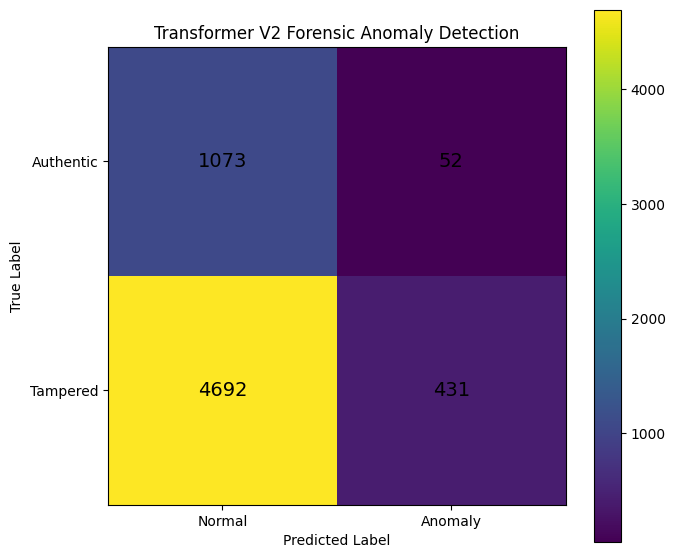


✓ V2 confusion matrix generated.


In [54]:
# ============================================================
# Cell 29: Transformer V2 Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# Calculate confusion matrix
# ------------------------------------------------------------

cm_v2 = confusion_matrix(
    test_labels_v2,
    test_predictions_v2
)

tn_v2, fp_v2, fn_v2, tp_v2 = cm_v2.ravel()

# ------------------------------------------------------------
# Display numerical results
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 CONFUSION MATRIX")
print("=" * 65)

print("\n                 Predicted")
print("                 Normal   Anomaly")
print(
    f"Authentic       {tn_v2:6d}   {fp_v2:6d}"
)
print(
    f"Tampered        {fn_v2:6d}   {tp_v2:6d}"
)

print("\n" + "-" * 65)

print(f"True Negatives  (TN) : {tn_v2}")
print(f"False Positives (FP) : {fp_v2}")
print(f"False Negatives (FN) : {fn_v2}")
print(f"True Positives  (TP) : {tp_v2}")

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    cm_v2,
    interpolation="nearest"
)

plt.title(
    "Transformer V2 Forensic Anomaly Detection"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Normal", "Anomaly"]
)

plt.yticks(
    [0, 1],
    ["Authentic", "Tampered"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values
for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            str(cm_v2[i, j]),
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()
plt.show()

print("\n✓ V2 confusion matrix generated.")

# Cell 30: Transformer V2 ROC-AUC Evaluation

This cell evaluates how well the reconstruction error separates authentic and tampered images across different possible thresholds.

ROC-AUC measures the overall ranking ability of the reconstruction error.

A higher AUC indicates better separation between the two classes.

Unlike the fixed anomaly threshold, ROC-AUC considers many possible thresholds.

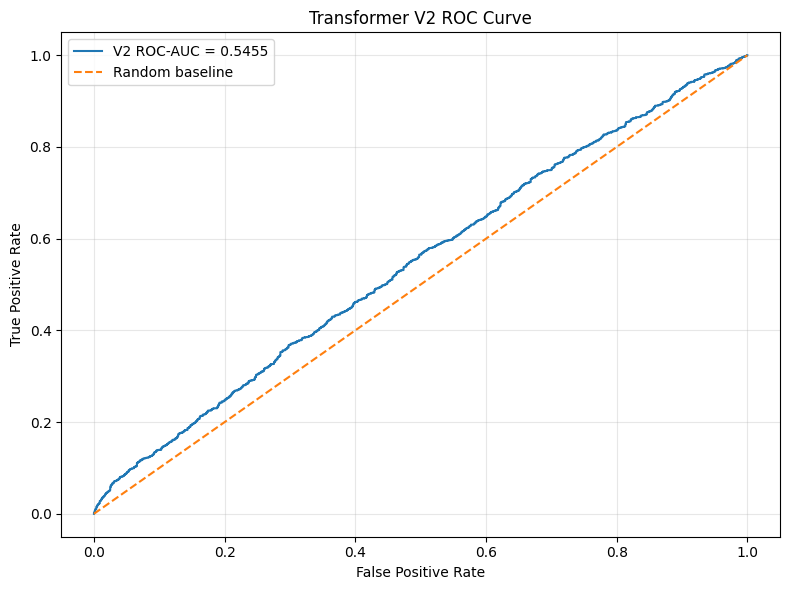

TRANSFORMER V2 ROC-AUC EVALUATION

ROC-AUC : 0.5455

Interpretation:
Higher AUC → better separation of authentic and tampered images.
AUC ≈ 0.50 → reconstruction error provides little ranking separation.
AUC > 0.50 → reconstruction error contains useful ranking information.

✓ V2 ROC curve and ROC-AUC calculated.


In [55]:
# ============================================================
# Cell 30: Transformer V2 ROC-AUC Evaluation
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

# ------------------------------------------------------------
# Calculate ROC-AUC
# ------------------------------------------------------------

v2_roc_auc = roc_auc_score(
    test_labels_v2,
    test_errors_v2
)

# ------------------------------------------------------------
# Calculate ROC curve
# ------------------------------------------------------------

v2_fpr, v2_tpr, v2_thresholds = roc_curve(
    test_labels_v2,
    test_errors_v2
)

# ------------------------------------------------------------
# Plot ROC curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    v2_fpr,
    v2_tpr,
    label=f"V2 ROC-AUC = {v2_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Transformer V2 ROC Curve"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 ROC-AUC EVALUATION")
print("=" * 65)

print(
    f"\nROC-AUC : {v2_roc_auc:.4f}"
)

print("\nInterpretation:")

print(
    "Higher AUC → better separation of "
    "authentic and tampered images."
)

print(
    "AUC ≈ 0.50 → reconstruction error "
    "provides little ranking separation."
)

print(
    "AUC > 0.50 → reconstruction error "
    "contains useful ranking information."
)

print("\n✓ V2 ROC curve and ROC-AUC calculated.")

# Cell 31: Transformer V2 Authentic vs Tampered Error Analysis

This cell compares the reconstruction errors of authentic and tampered test images.

The goal is to determine whether tampered images generally produce higher reconstruction errors than authentic images.

The distributions may overlap because reconstruction error alone is not a perfect tampering detector.

This analysis helps us understand the forensic behavior of the Transformer V2 model.

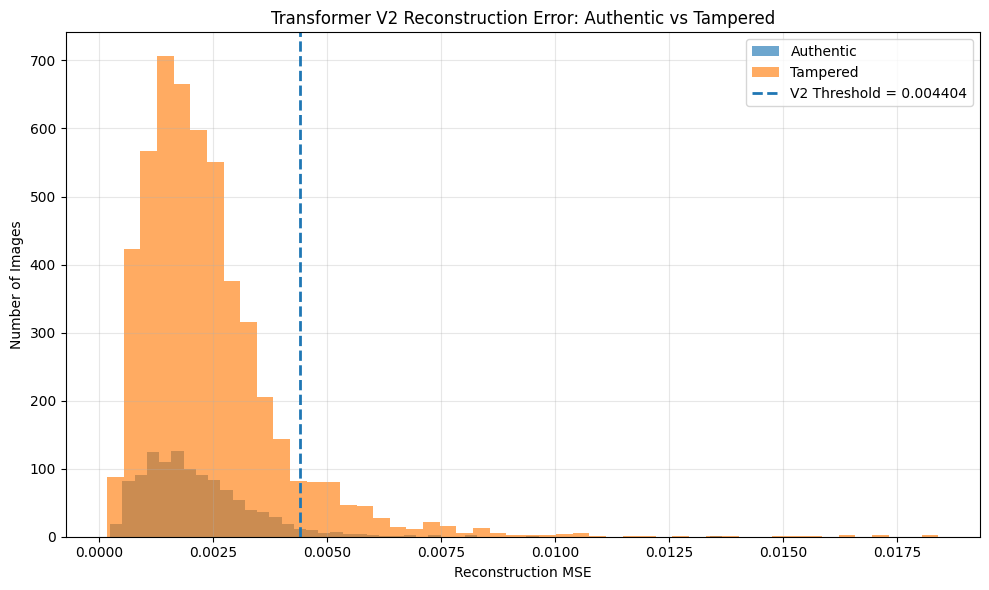

TRANSFORMER V2 AUTHENTIC VS TAMPERED ERROR ANALYSIS

Authentic:
  Count  : 1125
  Mean   : 0.002122
  Median : 0.001881
  Std    : 0.001233

Tampered:
  Count  : 5123
  Mean   : 0.002391
  Median : 0.002057
  Std    : 0.001579

Mean reconstruction-error ratio:
  Tampered / Authentic : 1.1271x

✓ V2 error distribution comparison completed.


In [56]:
# ============================================================
# Cell 31: Transformer V2 Authentic vs Tampered Error Analysis
# ============================================================

# ------------------------------------------------------------
# Separate reconstruction errors by class
# ------------------------------------------------------------

authentic_errors_v2 = test_errors_v2[
    test_labels_v2 == 0
]

tampered_errors_v2 = test_errors_v2[
    test_labels_v2 == 1
]

# ------------------------------------------------------------
# Calculate statistics
# ------------------------------------------------------------

auth_mean_v2 = np.mean(
    authentic_errors_v2
)

auth_median_v2 = np.median(
    authentic_errors_v2
)

auth_std_v2 = np.std(
    authentic_errors_v2
)

tampered_mean_v2 = np.mean(
    tampered_errors_v2
)

tampered_median_v2 = np.median(
    tampered_errors_v2
)

tampered_std_v2 = np.std(
    tampered_errors_v2
)

mean_ratio_v2 = (
    tampered_mean_v2 / auth_mean_v2
    if auth_mean_v2 > 0
    else np.nan
)

# ------------------------------------------------------------
# Plot distributions
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    authentic_errors_v2,
    bins=50,
    alpha=0.65,
    label="Authentic"
)

plt.hist(
    tampered_errors_v2,
    bins=50,
    alpha=0.65,
    label="Tampered"
)

plt.axvline(
    ANOMALY_THRESHOLD_V2,
    linestyle="--",
    linewidth=2,
    label=f"V2 Threshold = {ANOMALY_THRESHOLD_V2:.6f}"
)

plt.xlabel(
    "Reconstruction MSE"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Transformer V2 Reconstruction Error: "
    "Authentic vs Tampered"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 AUTHENTIC VS TAMPERED ERROR ANALYSIS")
print("=" * 65)

print("\nAuthentic:")

print(
    f"  Count  : {len(authentic_errors_v2)}"
)

print(
    f"  Mean   : {auth_mean_v2:.6f}"
)

print(
    f"  Median : {auth_median_v2:.6f}"
)

print(
    f"  Std    : {auth_std_v2:.6f}"
)

print("\nTampered:")

print(
    f"  Count  : {len(tampered_errors_v2)}"
)

print(
    f"  Mean   : {tampered_mean_v2:.6f}"
)

print(
    f"  Median : {tampered_median_v2:.6f}"
)

print(
    f"  Std    : {tampered_std_v2:.6f}"
)

print("\nMean reconstruction-error ratio:")

print(
    f"  Tampered / Authentic : "
    f"{mean_ratio_v2:.4f}x"
)

print("\n✓ V2 error distribution comparison completed.")

# Cell 32: Transformer V2 Original vs Reconstructed Images

This cell compares original test images with their reconstructed versions.

Both authentic and tampered images are displayed.

The reconstruction error (MSE) is shown for each image.

This visualization helps us understand how the Transformer V2 represents and reconstructs different types of images.

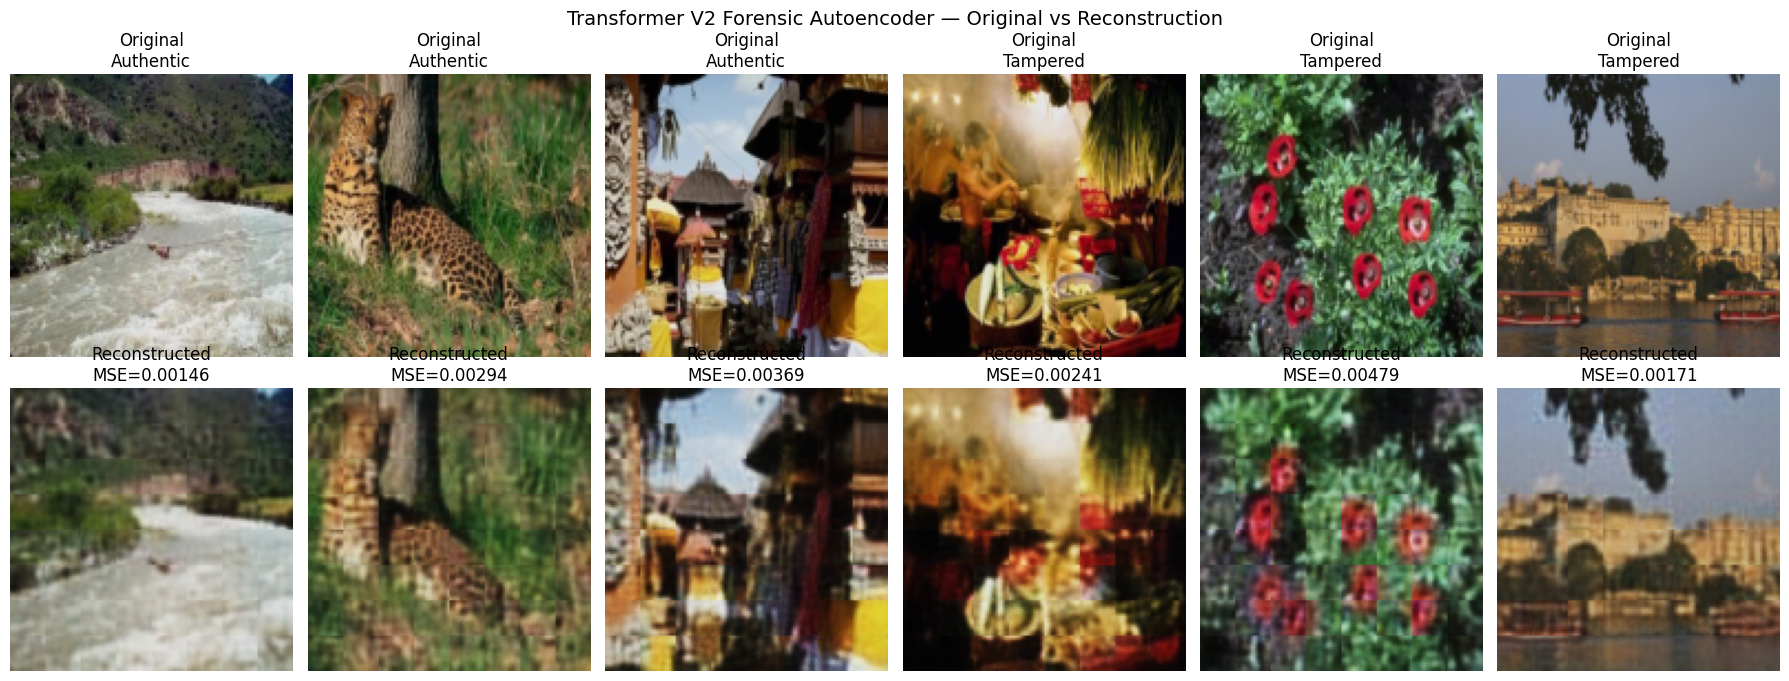

V2 ORIGINAL VS RECONSTRUCTED VISUALIZATION

Authentic samples : 3
Tampered samples  : 3

✓ V2 reconstruction visualization completed.


In [57]:
# ============================================================
# Cell 32: Transformer V2 Original vs Reconstructed Images
# ============================================================

import random
import torch
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# Select samples
# ------------------------------------------------------------

random.seed(SEED)

authentic_samples_v2 = test_results_v2[
    test_results_v2["true_label"] == 0
].sample(
    n=3,
    random_state=SEED
)

tampered_samples_v2 = test_results_v2[
    test_results_v2["true_label"] == 1
].sample(
    n=3,
    random_state=SEED
)

selected_samples_v2 = pd.concat([
    authentic_samples_v2,
    tampered_samples_v2
]).reset_index(drop=True)

# ------------------------------------------------------------
# Load images and reconstruct
# ------------------------------------------------------------

original_images_v2 = []
reconstructed_images_v2 = []
sample_errors_v2 = []

transformer_model.eval()

with torch.no_grad():

    for _, row in selected_samples_v2.iterrows():

        image = Image.open(
            row["path"]
        ).convert("RGB")

        image_tensor = transform(
            image
        ).unsqueeze(0).to(device)

        reconstructed, _, _ = transformer_model(
            image_tensor
        )

        reconstruction = (
            reconstructed[0]
            .cpu()
            .numpy()
            .transpose(1, 2, 0)
        )

        original = (
            image_tensor[0]
            .cpu()
            .numpy()
            .transpose(1, 2, 0)
        )

        original_images_v2.append(
            original
        )

        reconstructed_images_v2.append(
            reconstruction
        )

        mse = np.mean(
            (original - reconstruction) ** 2
        )

        sample_errors_v2.append(mse)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    6,
    figsize=(18, 7)
)

for i in range(6):

    # Original
    axes[0, i].imshow(
        original_images_v2[i]
    )

    label = (
        "Authentic"
        if selected_samples_v2.iloc[i]["true_label"] == 0
        else "Tampered"
    )

    axes[0, i].set_title(
        f"Original\n{label}"
    )

    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(
        reconstructed_images_v2[i]
    )

    axes[1, i].set_title(
        f"Reconstructed\nMSE={sample_errors_v2[i]:.5f}"
    )

    axes[1, i].axis("off")

plt.suptitle(
    "Transformer V2 Forensic Autoencoder — Original vs Reconstruction",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 65)
print("V2 ORIGINAL VS RECONSTRUCTED VISUALIZATION")
print("=" * 65)

print(
    "\nAuthentic samples : 3"
)

print(
    "Tampered samples  : 3"
)

print(
    "\n✓ V2 reconstruction visualization completed."
)

# Cell 33: Transformer V2 Reconstruction Difference Maps

This cell visualizes the pixel-wise difference between the original
image and its reconstructed image.

Bright regions represent areas where the reconstruction differs more
strongly from the original.

These maps help visualize reconstruction behavior and may highlight
regions that contribute strongly to the anomaly score.

Important:
These are reconstruction-error maps, not definitive tampering
localization maps. Additional forensic validation is required before
interpreting a highlighted region as evidence of manipulation.

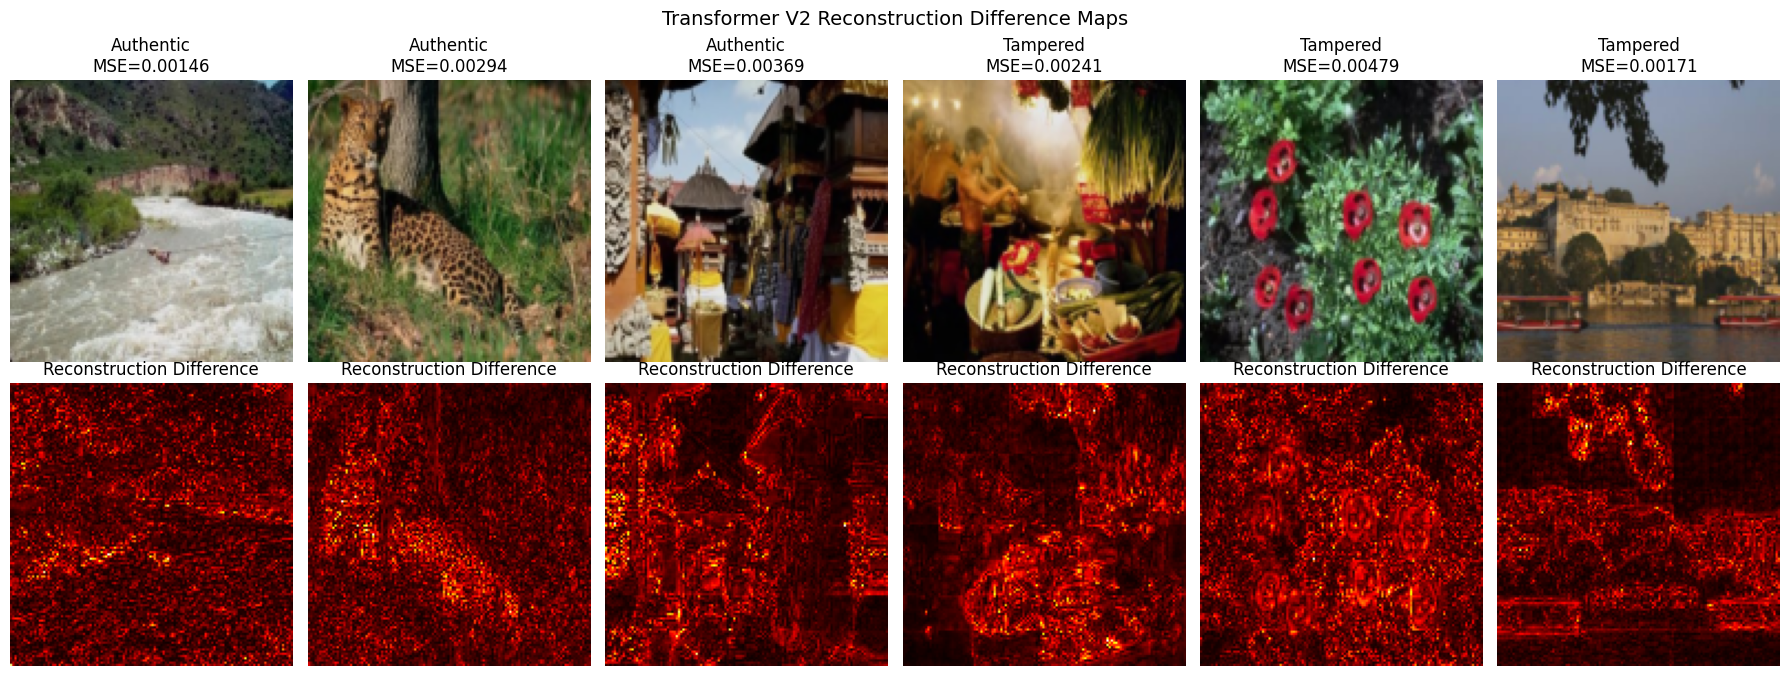

V2 RECONSTRUCTION ERROR MAP ANALYSIS

Top row    : Original test images
Bottom row : Pixel-wise reconstruction difference

Important:
Bright regions indicate larger reconstruction differences.
They should NOT be interpreted as definitive tampering localization.
Additional forensic validation is required.

✓ V2 reconstruction difference maps generated.


In [58]:
# ============================================================
# Cell 33: Transformer V2 Reconstruction Difference Maps
# ============================================================

# ------------------------------------------------------------
# Calculate absolute reconstruction differences
# ------------------------------------------------------------

difference_maps_v2 = []

for i in range(len(original_images_v2)):

    original = original_images_v2[i]

    reconstruction = reconstructed_images_v2[i]

    # Pixel-wise absolute difference
    difference = np.abs(
        original - reconstruction
    )

    # Convert RGB difference to grayscale
    difference_gray = np.mean(
        difference,
        axis=2
    )

    difference_maps_v2.append(
        difference_gray
    )

# ------------------------------------------------------------
# Display original + error maps
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    6,
    figsize=(18, 7)
)

for i in range(6):

    # --------------------------------------------------------
    # Original image
    # --------------------------------------------------------

    axes[0, i].imshow(
        original_images_v2[i]
    )

    label = (
        "Authentic"
        if selected_samples_v2.iloc[i]["true_label"] == 0
        else "Tampered"
    )

    axes[0, i].set_title(
        f"{label}\n"
        f"MSE={sample_errors_v2[i]:.5f}"
    )

    axes[0, i].axis("off")

    # --------------------------------------------------------
    # Reconstruction error
    # --------------------------------------------------------

    axes[1, i].imshow(
        difference_maps_v2[i],
        cmap="hot"
    )

    axes[1, i].set_title(
        "Reconstruction Difference"
    )

    axes[1, i].axis("off")

plt.suptitle(
    "Transformer V2 Reconstruction Difference Maps",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 65)
print("V2 RECONSTRUCTION ERROR MAP ANALYSIS")
print("=" * 65)

print(
    "\nTop row    : Original test images"
)

print(
    "Bottom row : Pixel-wise reconstruction difference"
)

print("\nImportant:")
print(
    "Bright regions indicate larger reconstruction differences."
)

print(
    "They should NOT be interpreted as definitive tampering "
    "localization."
)

print(
    "Additional forensic validation is required."
)

print("\n✓ V2 reconstruction difference maps generated.")

# Cell 34: Transformer V2 Attention Visualization

This cell visualizes the Transformer's attention across the image patches.

The 128×128 image is divided into 64 patches of 16×16 pixels.

The Transformer learns relationships between these patches using self-attention.

The attention visualization helps us understand which image regions receive stronger attention during feature extraction.

This visualization is for model interpretation and should not be treated as definitive evidence of manipulation.

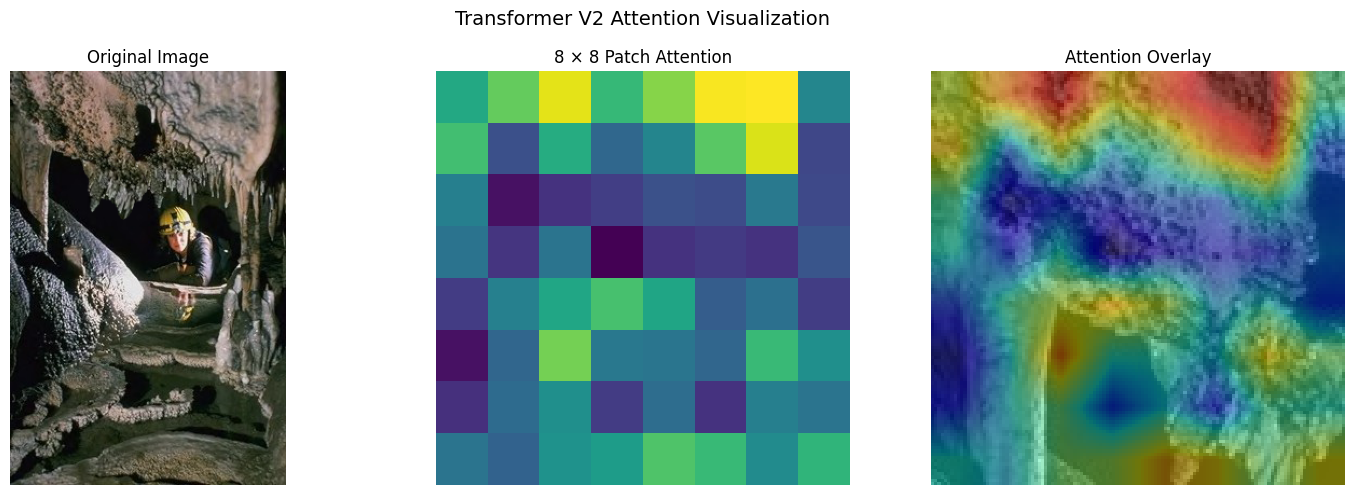

TRANSFORMER V2 ATTENTION ANALYSIS

Image:
/content/casia_v2/CASIA2/Tp/Tp_S_NNN_S_N_ind00061_ind00061_00908.tif

Patch configuration:
Image size     : 128 × 128
Patch size     : 16 × 16
Total patches  : 64
Patch grid     : 8 × 8

Attention layers: 4

Attention matrix shape: (64, 64)

Important:
Attention shows model focus/relationships between patches.
It should NOT be interpreted as definitive tampering localization.

✓ V2 attention visualization completed.


In [59]:
# ============================================================
# Cell 34: Transformer V2 Attention Visualization
# ============================================================

# ------------------------------------------------------------
# Select one test image
# ------------------------------------------------------------

attention_sample = test_results_v2.iloc[0]

attention_image_path = attention_sample["path"]

attention_image = Image.open(
    attention_image_path
).convert("RGB")

attention_tensor = transform(
    attention_image
).unsqueeze(0).to(device)

# ------------------------------------------------------------
# Run Transformer V2
# ------------------------------------------------------------

transformer_model.eval()

with torch.no_grad():

    reconstructed, latent, attention_maps = transformer_model(
        attention_tensor
    )

# ------------------------------------------------------------
# Get final encoder attention
# ------------------------------------------------------------

final_attention = attention_maps[-1]

# Shape is expected to be:
# [1, 64, 64]

attention_matrix = final_attention[0].cpu().numpy()

# ------------------------------------------------------------
# Calculate average attention received by each patch
# ------------------------------------------------------------

patch_attention = attention_matrix.mean(
    axis=0
)

# ------------------------------------------------------------
# Reshape 64 patches → 8 × 8
# ------------------------------------------------------------

attention_grid = patch_attention.reshape(
    8,
    8
)

# Normalize for visualization

attention_grid = (
    attention_grid - attention_grid.min()
) / (
    attention_grid.max()
    - attention_grid.min()
    + 1e-8
)

# ------------------------------------------------------------
# Resize attention map to image size
# ------------------------------------------------------------

attention_map = Image.fromarray(
    (attention_grid * 255).astype(np.uint8)
)

attention_map = attention_map.resize(
    (IMAGE_SIZE, IMAGE_SIZE),
    Image.Resampling.BILINEAR
)

attention_map = np.array(
    attention_map
) / 255.0

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Original
axes[0].imshow(
    attention_image
)

axes[0].set_title(
    "Original Image"
)

axes[0].axis("off")

# Patch attention
axes[1].imshow(
    attention_grid,
    cmap="viridis"
)

axes[1].set_title(
    "8 × 8 Patch Attention"
)

axes[1].axis("off")

# Attention overlay
axes[2].imshow(
    attention_image
)

axes[2].imshow(
    attention_map,
    cmap="jet",
    alpha=0.45
)

axes[2].set_title(
    "Attention Overlay"
)

axes[2].axis("off")

plt.suptitle(
    "Transformer V2 Attention Visualization",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 ATTENTION ANALYSIS")
print("=" * 65)

print(
    "\nImage:"
)

print(
    attention_image_path
)

print(
    "\nPatch configuration:"
)

print(
    "Image size     : 128 × 128"
)

print(
    "Patch size     : 16 × 16"
)

print(
    "Total patches  : 64"
)

print(
    "Patch grid     : 8 × 8"
)

print(
    "\nAttention layers:",
    len(attention_maps)
)

print(
    "\nAttention matrix shape:",
    attention_matrix.shape
)

print("\nImportant:")
print(
    "Attention shows model focus/relationships between patches."
)

print(
    "It should NOT be interpreted as definitive tampering localization."
)

print(
    "\n✓ V2 attention visualization completed."
)

# Cell 35: Single-Image Transformer V2 Forensic Analysis

This cell performs a detailed analysis of one test image.

The model reconstructs the image and calculates its reconstruction MSE.

The MSE is compared with the V2 anomaly threshold.

The result is reported as either:

- Normal
- Potential Anomaly

The result is an AI-based screening result and should not be treated as definitive proof of image manipulation.

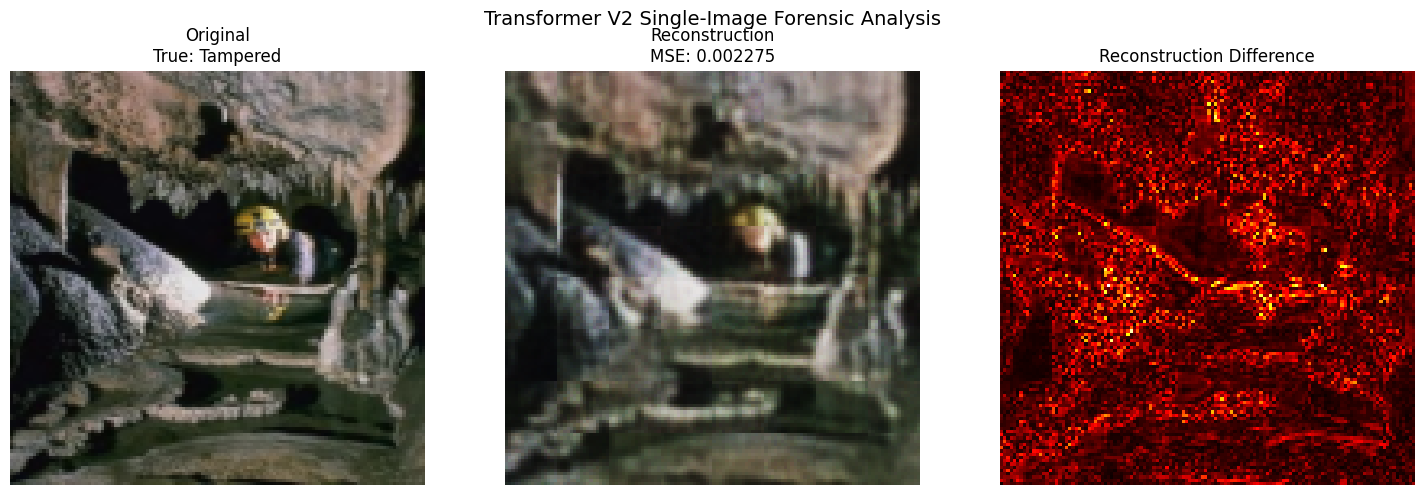

TRANSFORMER V2 SINGLE-IMAGE FORENSIC ANALYSIS

Image path:
/content/casia_v2/CASIA2/Tp/Tp_S_NNN_S_N_ind00061_ind00061_00908.tif

True class:
Tampered

Reconstruction MSE:
0.002275

Anomaly threshold:
0.004404

AI screening result:
Normal

Latent representation:
torch.Size([1, 256])

Attention layers:
4

Interpretation:
The reconstruction error is within the learned authentic-image range.
The image is not flagged by this reconstruction-based screen.

Important: This AI result is a screening indication, not definitive proof of manipulation.

✓ Single-image V2 forensic analysis completed.


In [60]:
# ============================================================
# Cell 35: Single-Image Transformer V2 Forensic Analysis
# ============================================================

# ------------------------------------------------------------
# Select one test image
# ------------------------------------------------------------

sample_index = 0

sample_row = test_results_v2.iloc[sample_index]

sample_path = sample_row["path"]

true_label = int(
    sample_row["true_label"]
)

# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------

sample_image = Image.open(
    sample_path
).convert("RGB")

sample_tensor = transform(
    sample_image
).unsqueeze(0).to(device)

# ------------------------------------------------------------
# Model inference
# ------------------------------------------------------------

transformer_model.eval()

with torch.no_grad():

    reconstructed, latent, attention_maps = transformer_model(
        sample_tensor
    )

# ------------------------------------------------------------
# Convert images
# ------------------------------------------------------------

original = (
    sample_tensor[0]
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

reconstruction = (
    reconstructed[0]
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

# ------------------------------------------------------------
# Calculate reconstruction error
# ------------------------------------------------------------

sample_mse = np.mean(
    (original - reconstruction) ** 2
)

# ------------------------------------------------------------
# Anomaly decision
# ------------------------------------------------------------

if sample_mse > ANOMALY_THRESHOLD_V2:
    prediction = "Potential Anomaly"
else:
    prediction = "Normal"

# ------------------------------------------------------------
# True class
# ------------------------------------------------------------

true_class = (
    "Tampered"
    if true_label == 1
    else "Authentic"
)

# ------------------------------------------------------------
# Difference map
# ------------------------------------------------------------

difference_map = np.mean(
    np.abs(
        original - reconstruction
    ),
    axis=2
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Original
axes[0].imshow(original)

axes[0].set_title(
    f"Original\nTrue: {true_class}"
)

axes[0].axis("off")

# Reconstruction
axes[1].imshow(reconstruction)

axes[1].set_title(
    f"Reconstruction\nMSE: {sample_mse:.6f}"
)

axes[1].axis("off")

# Difference
axes[2].imshow(
    difference_map,
    cmap="hot"
)

axes[2].set_title(
    "Reconstruction Difference"
)

axes[2].axis("off")

plt.suptitle(
    "Transformer V2 Single-Image Forensic Analysis",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print forensic summary
# ------------------------------------------------------------

print("=" * 65)
print("TRANSFORMER V2 SINGLE-IMAGE FORENSIC ANALYSIS")
print("=" * 65)

print("\nImage path:")
print(sample_path)

print("\nTrue class:")
print(true_class)

print("\nReconstruction MSE:")
print(
    f"{sample_mse:.6f}"
)

print("\nAnomaly threshold:")
print(
    f"{ANOMALY_THRESHOLD_V2:.6f}"
)

print("\nAI screening result:")
print(
    prediction
)

print("\nLatent representation:")
print(
    latent.shape
)

print("\nAttention layers:")
print(
    len(attention_maps)
)

print("\nInterpretation:")

if prediction == "Potential Anomaly":

    print(
        "The reconstruction error is above the learned "
        "authentic-image threshold."
    )

    print(
        "The image is therefore flagged for further "
        "forensic review."
    )

else:

    print(
        "The reconstruction error is within the learned "
        "authentic-image range."
    )

    print(
        "The image is not flagged by this reconstruction-based screen."
    )

print(
    "\nImportant: This AI result is a screening indication, "
    "not definitive proof of manipulation."
)

print("\n✓ Single-image V2 forensic analysis completed.")

# Cell 36: Final Transformer V2 Forensic Report

This cell summarizes the complete Transformer V2 forensic experiment.

It combines:

- Model architecture
- Training performance
- Reconstruction quality
- Anomaly threshold
- Test-set performance
- ROC-AUC
- Confusion matrix
- Forensic interpretation

The Transformer V2 model is designed as an AI-based screening system for digital image evidence.

The output indicates potential anomalies and should not be considered definitive proof of image manipulation.

In [61]:
# ============================================================
# Cell 36: Final Transformer V2 Forensic Report
# ============================================================

print("=" * 75)
print("       AI DIGITAL EVIDENCE INTELLIGENCE PLATFORM")
print("       TRANSFORMER V2 FORENSIC IMAGE ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# MODEL INFORMATION
# ------------------------------------------------------------

print("\n1. MODEL CONFIGURATION")
print("-" * 75)

print(f"Image size              : {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Patch size              : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Number of patches       : {NUM_PATCHES}")
print(f"Embedding dimension     : {EMBED_DIM}")
print(f"Attention heads         : {NUM_HEADS}")
print(f"Encoder layers          : {NUM_ENCODER_LAYERS}")
print(f"Decoder layers          : 2")
print(f"Feed-forward dimension  : {FF_DIM}")

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

print("\n2. TRAINING PERFORMANCE")
print("-" * 75)

print(f"Training epochs         : {len(train_losses)}")
print(f"Best epoch              : {best_epoch}")
print(f"Final training MSE      : {train_losses[-1]:.6f}")
print(f"Best validation MSE     : {best_val_loss:.6f}")

# ------------------------------------------------------------
# RECONSTRUCTION QUALITY
# ------------------------------------------------------------

print("\n3. RECONSTRUCTION QUALITY")
print("-" * 75)

print(
    f"Mean PSNR               : "
    f"{psnr_scores.mean():.4f} dB"
)

print(
    f"Mean SSIM               : "
    f"{ssim_scores.mean():.4f}"
)

# ------------------------------------------------------------
# ANOMALY THRESHOLD
# ------------------------------------------------------------

print("\n4. ANOMALY DETECTION")
print("-" * 75)

print(
    f"Threshold percentile    : 95th"
)

print(
    f"Anomaly threshold       : "
    f"{ANOMALY_THRESHOLD_V2:.6f}"
)

print(
    "Above threshold        : Potential Anomaly"
)

# ------------------------------------------------------------
# TEST DATA
# ------------------------------------------------------------

print("\n5. TEST DATA")
print("-" * 75)

print(
    f"Total test images       : "
    f"{len(test_labels_v2)}"
)

print(
    f"Authentic images        : "
    f"{np.sum(test_labels_v2 == 0)}"
)

print(
    f"Tampered images         : "
    f"{np.sum(test_labels_v2 == 1)}"
)

# ------------------------------------------------------------
# CLASSIFICATION METRICS
# ------------------------------------------------------------

print("\n6. CLASSIFICATION PERFORMANCE")
print("-" * 75)

print(
    f"Accuracy                : "
    f"{v2_accuracy:.4f}"
)

print(
    f"Precision               : "
    f"{v2_precision:.4f}"
)

print(
    f"Recall                  : "
    f"{v2_recall:.4f}"
)

print(
    f"F1-Score                : "
    f"{v2_f1:.4f}"
)

print(
    f"Balanced Accuracy       : "
    f"{v2_balanced_accuracy:.4f}"
)

print(
    f"ROC-AUC                 : "
    f"{v2_roc_auc:.4f}"
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("\n7. CONFUSION MATRIX")
print("-" * 75)

print(f"True Negatives (TN)     : {tn_v2}")
print(f"False Positives (FP)    : {fp_v2}")
print(f"False Negatives (FN)    : {fn_v2}")
print(f"True Positives (TP)     : {tp_v2}")

# ------------------------------------------------------------
# FORENSIC INTERPRETATION
# ------------------------------------------------------------

print("\n8. FORENSIC INTERPRETATION")
print("-" * 75)

print(
    "The Transformer V2 model learns reconstruction patterns "
    "from authentic images."
)

print(
    "Reconstruction error is used as an anomaly score."
)

print(
    "The model shows improved reconstruction quality and "
    "better ROC-AUC compared with the previous V1 model."
)

print(
    "However, reconstruction error alone provides limited "
    "separation between authentic and tampered images."
)

print(
    "Therefore, the system should be used as an AI-assisted "
    "forensic screening tool."
)

print(
    "A Potential Anomaly result should trigger further "
    "forensic examination rather than being treated as proof."
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL TRANSFORMER V2 SUMMARY")
print("=" * 75)

print(
    f"\n✓ Best validation MSE : {best_val_loss:.6f}"
)

print(
    f"✓ Mean PSNR           : {psnr_scores.mean():.4f} dB"
)

print(
    f"✓ Mean SSIM           : {ssim_scores.mean():.4f}"
)

print(
    f"✓ Anomaly threshold   : {ANOMALY_THRESHOLD_V2:.6f}"
)

print(
    f"✓ ROC-AUC             : {v2_roc_auc:.4f}"
)

print(
    "\n✓ Transformer V2 forensic evaluation completed."
)

       AI DIGITAL EVIDENCE INTELLIGENCE PLATFORM
       TRANSFORMER V2 FORENSIC IMAGE ANALYSIS

1. MODEL CONFIGURATION
---------------------------------------------------------------------------
Image size              : 128 × 128
Patch size              : 16 × 16
Number of patches       : 64
Embedding dimension     : 256
Attention heads         : 8
Encoder layers          : 4
Decoder layers          : 2
Feed-forward dimension  : 512

2. TRAINING PERFORMANCE
---------------------------------------------------------------------------
Training epochs         : 50
Best epoch              : 50
Final training MSE      : 0.002569
Best validation MSE     : 0.002060

3. RECONSTRUCTION QUALITY
---------------------------------------------------------------------------
Mean PSNR               : 27.5793 dB
Mean SSIM               : 0.8498

4. ANOMALY DETECTION
---------------------------------------------------------------------------
Threshold percentile    : 95th
Anomaly threshold       : 0.004

# Cell 37: Save Transformer V2 Model & Final Results

In [70]:
FINAL_V2_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "transformer_v2_final.pth"
)

torch.save(
    {
        "model_state_dict": transformer_model.state_dict(),

        "architecture": "Transformer Forensic Autoencoder V2",

        "image_size": IMAGE_SIZE,
        "patch_size": PATCH_SIZE,
        "num_patches": NUM_PATCHES,
        "embed_dim": EMBED_DIM,
        "num_heads": NUM_HEADS,
        "encoder_layers": NUM_ENCODER_LAYERS,
        "decoder_layers": 2,
        "ff_dim": FF_DIM,

        "epoch": len(train_losses),

        "train_mse": float(train_losses[-1]),

        "validation_mse": float(best_val_loss),

        "anomaly_threshold": float(
            ANOMALY_THRESHOLD_V2
        ),

        "roc_auc": float(
            v2_roc_auc
        ),

        "accuracy": float(
            v2_accuracy
        ),

        "precision": float(
            v2_precision
        ),

        "recall": float(
            v2_recall
        ),

        "f1_score": float(
            v2_f1
        ),

        "balanced_accuracy": float(
            v2_balanced_accuracy
        )
    },
    FINAL_V2_MODEL_PATH
)

# ------------------------------------------------------------
# Save final metrics
# ------------------------------------------------------------

FINAL_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "transformer_v2_final_metrics.npz"
)

np.savez(
    FINAL_METRICS_PATH,

    train_mse=float(train_losses[-1]),

    validation_mse=float(best_val_loss),

    mean_psnr=float(psnr_scores.mean()),

    mean_ssim=float(ssim_scores.mean()),

    anomaly_threshold=float(
        ANOMALY_THRESHOLD_V2
    ),

    accuracy=float(v2_accuracy),

    precision=float(v2_precision),

    recall=float(v2_recall),

    f1_score=float(v2_f1),

    balanced_accuracy=float(
        v2_balanced_accuracy
    ),

    roc_auc=float(v2_roc_auc),

    true_negatives=int(tn_v2),

    false_positives=int(fp_v2),

    false_negatives=int(fn_v2),

    true_positives=int(tp_v2)
)

# ------------------------------------------------------------
# Save reconstruction error arrays
# ------------------------------------------------------------

V2_ERROR_DATA_PATH = os.path.join(
    RESULTS_DIR,
    "transformer_v2_error_data.npz"
)

np.savez(
    V2_ERROR_DATA_PATH,

    validation_errors=validation_errors_v2,

    test_errors=test_errors_v2,

    test_labels=test_labels_v2,

    anomaly_threshold=ANOMALY_THRESHOLD_V2
)

# ------------------------------------------------------------
# Display saved files
# ------------------------------------------------------------

print("=" * 70)
print("TRANSFORMER V2 FINAL FILES SAVED")
print("=" * 70)

print("\nModel:")
print(FINAL_V2_MODEL_PATH)

print("\nMetrics:")
print(FINAL_METRICS_PATH)

print("\nError data:")
print(V2_ERROR_DATA_PATH)

print("\nTest results:")
print(V2_RESULTS_PATH)

print("\nThreshold:")
print(V2_THRESHOLD_PATH)

print("\n" + "-" * 70)

print("Saved contents:")
print("✓ Final Transformer V2 model")
print("✓ Model architecture configuration")
print("✓ Training and validation performance")
print("✓ Reconstruction quality metrics")
print("✓ Anomaly threshold")
print("✓ Classification metrics")
print("✓ ROC-AUC")
print("✓ Confusion matrix values")
print("✓ Validation/test reconstruction errors")
print("✓ Test predictions")

print("\n" + "=" * 70)
print("TRANSFORMER V2 PIPELINE COMPLETED")
print("=" * 70)

print("\n✓ Model saved successfully.")
print("✓ Results saved successfully.")
print("✓ Transformer V2 experiment is complete.")

TRANSFORMER V2 FINAL FILES SAVED

Model:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/checkpoints/transformer_v2_final.pth

Metrics:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/results/transformer_v2_final_metrics.npz

Error data:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/results/transformer_v2_error_data.npz

Test results:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/results/transformer_v2_test_results.csv

Threshold:
/content/AI-Digital-Evidence-Intelligence-Platform/transformer/results/transformer_v2_anomaly_threshold.npz

----------------------------------------------------------------------
Saved contents:
✓ Final Transformer V2 model
✓ Model architecture configuration
✓ Training and validation performance
✓ Reconstruction quality metrics
✓ Anomaly threshold
✓ Classification metrics
✓ ROC-AUC
✓ Confusion matrix values
✓ Validation/test reconstruction errors
✓ Test predictions

TRANSFORMER V2 PIPELINE COMPL

In [71]:
# Download final Transformer V2 model

from google.colab import files

FINAL_V2_MODEL_PATH = (
    "/content/AI-Digital-Evidence-Intelligence-Platform/"
    "transformer/checkpoints/transformer_v2_final.pth"
)

files.download(FINAL_V2_MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 38: Real Forensic Image Testing

REAL FORENSIC IMAGE TEST — TRANSFORMER V2


Saving evidence.jpeg to evidence (1).jpeg

Uploaded image:
evidence (1).jpeg
Original image size : (900, 1600)


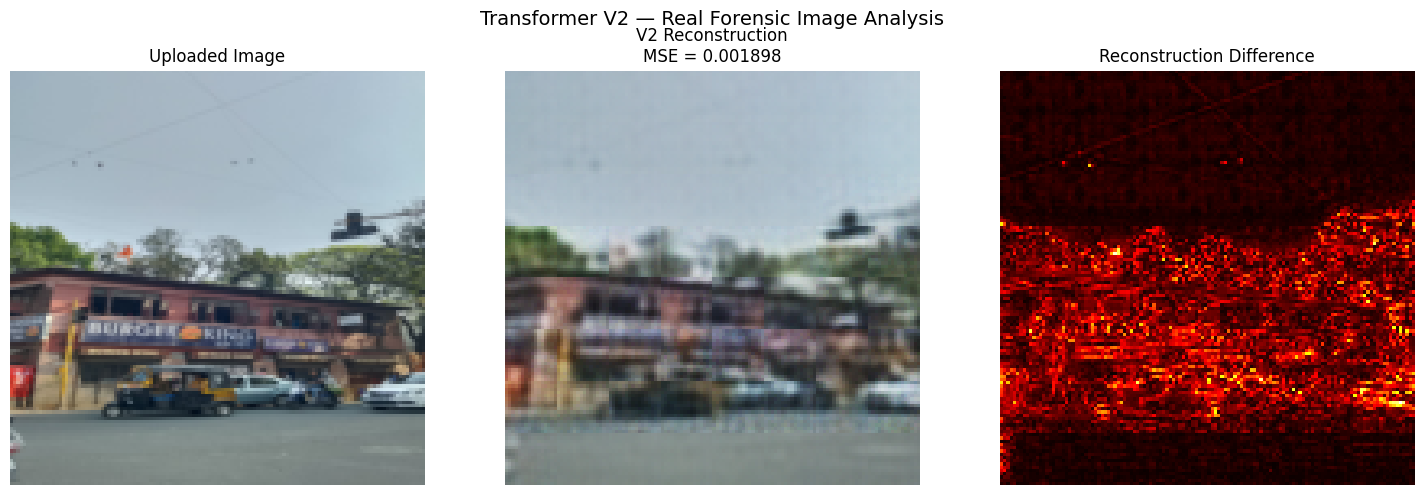


REAL FORENSIC ANALYSIS RESULT

File:
evidence (1).jpeg

Processed size:
128 × 128 RGB

Reconstruction MSE:
0.001898

V2 anomaly threshold:
0.004404

AI screening result:
NORMAL

Latent representation:
torch.Size([1, 256])

Attention layers:
4

Interpretation:
The image has a reconstruction error within the learned authentic-image range.
It is not flagged by the Transformer V2 reconstruction-based screen.

IMPORTANT:
This result does NOT prove that an image is authentic or manipulated.
It is an AI-assisted forensic screening result.

✓ Real forensic image testing completed.


In [68]:


from google.colab import files
from PIL import Image
import io
import numpy as np
import torch
import matplotlib.pyplot as plt

print("=" * 70)
print("REAL FORENSIC IMAGE TEST — TRANSFORMER V2")
print("=" * 70)

# ------------------------------------------------------------
# Upload image
# ------------------------------------------------------------

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No image was uploaded.")

file_name = list(uploaded.keys())[0]

print("\nUploaded image:")
print(file_name)

# ------------------------------------------------------------
# Open image
# ------------------------------------------------------------

image = Image.open(
    io.BytesIO(uploaded[file_name])
).convert("RGB")

print(
    "Original image size :",
    image.size
)

# ------------------------------------------------------------
# Preprocess
# ------------------------------------------------------------

image_tensor = transform(
    image
).unsqueeze(0).to(device)

# ------------------------------------------------------------
# Transformer V2 inference
# ------------------------------------------------------------

transformer_model.eval()

with torch.no_grad():

    reconstructed, latent, attention_maps = transformer_model(
        image_tensor
    )

# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

original = (
    image_tensor[0]
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

reconstruction = (
    reconstructed[0]
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

# ------------------------------------------------------------
# Reconstruction MSE
# ------------------------------------------------------------

mse = np.mean(
    (original - reconstruction) ** 2
)

# ------------------------------------------------------------
# Difference map
# ------------------------------------------------------------

difference = np.mean(
    np.abs(original - reconstruction),
    axis=2
)

# ------------------------------------------------------------
# Anomaly decision
# ------------------------------------------------------------

if mse > ANOMALY_THRESHOLD_V2:
    result = "POTENTIAL ANOMALY"
else:
    result = "NORMAL"

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Uploaded Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(reconstruction)
plt.title(
    f"V2 Reconstruction\nMSE = {mse:.6f}"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference, cmap="hot")
plt.title("Reconstruction Difference")
plt.axis("off")

plt.suptitle(
    "Transformer V2 — Real Forensic Image Analysis",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final forensic result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REAL FORENSIC ANALYSIS RESULT")
print("=" * 70)

print("\nFile:")
print(file_name)

print("\nProcessed size:")
print("128 × 128 RGB")

print("\nReconstruction MSE:")
print(f"{mse:.6f}")

print("\nV2 anomaly threshold:")
print(f"{ANOMALY_THRESHOLD_V2:.6f}")

print("\nAI screening result:")
print(result)

print("\nLatent representation:")
print(latent.shape)

print("\nAttention layers:")
print(len(attention_maps))

print("\nInterpretation:")

if mse > ANOMALY_THRESHOLD_V2:

    print(
        "The image has a reconstruction error above "
        "the authentic-image threshold."
    )

    print(
        "It is flagged as a potential anomaly and "
        "requires further forensic examination."
    )

else:

    print(
        "The image has a reconstruction error within "
        "the learned authentic-image range."
    )

    print(
        "It is not flagged by the Transformer V2 "
        "reconstruction-based screen."
    )

print(
    "\nIMPORTANT:"
)

print(
    "This result does NOT prove that an image is "
    "authentic or manipulated."
)

print(
    "It is an AI-assisted forensic screening result."
)

print("\n✓ Real forensic image testing completed.")

REAL FORENSIC IMAGE TEST — TRANSFORMER V2


Saving evidence3.jpeg to evidence3 (1).jpeg

Uploaded image:
evidence3 (1).jpeg
Original image size : (900, 1600)


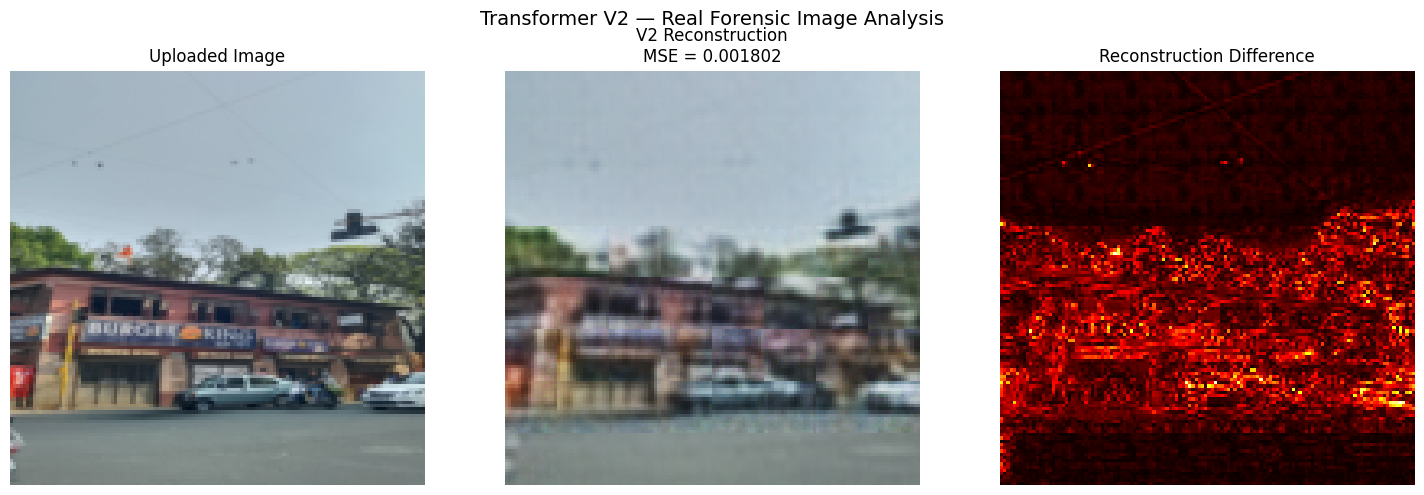


REAL FORENSIC ANALYSIS RESULT

File:
evidence3 (1).jpeg

Processed size:
128 × 128 RGB

Reconstruction MSE:
0.001802

V2 anomaly threshold:
0.004404

AI screening result:
NORMAL

Latent representation:
torch.Size([1, 256])

Attention layers:
4

Interpretation:
The image has a reconstruction error within the learned authentic-image range.
It is not flagged by the Transformer V2 reconstruction-based screen.

IMPORTANT:
This result does NOT prove that an image is authentic or manipulated.
It is an AI-assisted forensic screening result.

✓ Real forensic image testing completed.


In [69]:


from google.colab import files
from PIL import Image
import io
import numpy as np
import torch
import matplotlib.pyplot as plt

print("=" * 70)
print("REAL FORENSIC IMAGE TEST — TRANSFORMER V2")
print("=" * 70)

# ------------------------------------------------------------
# Upload image
# ------------------------------------------------------------

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No image was uploaded.")

file_name = list(uploaded.keys())[0]

print("\nUploaded image:")
print(file_name)

# ------------------------------------------------------------
# Open image
# ------------------------------------------------------------

image = Image.open(
    io.BytesIO(uploaded[file_name])
).convert("RGB")

print(
    "Original image size :",
    image.size
)

# ------------------------------------------------------------
# Preprocess
# ------------------------------------------------------------

image_tensor = transform(
    image
).unsqueeze(0).to(device)

# ------------------------------------------------------------
# Transformer V2 inference
# ------------------------------------------------------------

transformer_model.eval()

with torch.no_grad():

    reconstructed, latent, attention_maps = transformer_model(
        image_tensor
    )

# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

original = (
    image_tensor[0]
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

reconstruction = (
    reconstructed[0]
    .cpu()
    .numpy()
    .transpose(1, 2, 0)
)

# ------------------------------------------------------------
# Reconstruction MSE
# ------------------------------------------------------------

mse = np.mean(
    (original - reconstruction) ** 2
)

# ------------------------------------------------------------
# Difference map
# ------------------------------------------------------------

difference = np.mean(
    np.abs(original - reconstruction),
    axis=2
)

# ------------------------------------------------------------
# Anomaly decision
# ------------------------------------------------------------

if mse > ANOMALY_THRESHOLD_V2:
    result = "POTENTIAL ANOMALY"
else:
    result = "NORMAL"

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Uploaded Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(reconstruction)
plt.title(
    f"V2 Reconstruction\nMSE = {mse:.6f}"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference, cmap="hot")
plt.title("Reconstruction Difference")
plt.axis("off")

plt.suptitle(
    "Transformer V2 — Real Forensic Image Analysis",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final forensic result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REAL FORENSIC ANALYSIS RESULT")
print("=" * 70)

print("\nFile:")
print(file_name)

print("\nProcessed size:")
print("128 × 128 RGB")

print("\nReconstruction MSE:")
print(f"{mse:.6f}")

print("\nV2 anomaly threshold:")
print(f"{ANOMALY_THRESHOLD_V2:.6f}")

print("\nAI screening result:")
print(result)

print("\nLatent representation:")
print(latent.shape)

print("\nAttention layers:")
print(len(attention_maps))

print("\nInterpretation:")

if mse > ANOMALY_THRESHOLD_V2:

    print(
        "The image has a reconstruction error above "
        "the authentic-image threshold."
    )

    print(
        "It is flagged as a potential anomaly and "
        "requires further forensic examination."
    )

else:

    print(
        "The image has a reconstruction error within "
        "the learned authentic-image range."
    )

    print(
        "It is not flagged by the Transformer V2 "
        "reconstruction-based screen."
    )

print(
    "\nIMPORTANT:"
)

print(
    "This result does NOT prove that an image is "
    "authentic or manipulated."
)

print(
    "It is an AI-assisted forensic screening result."
)

print("\n✓ Real forensic image testing completed.")